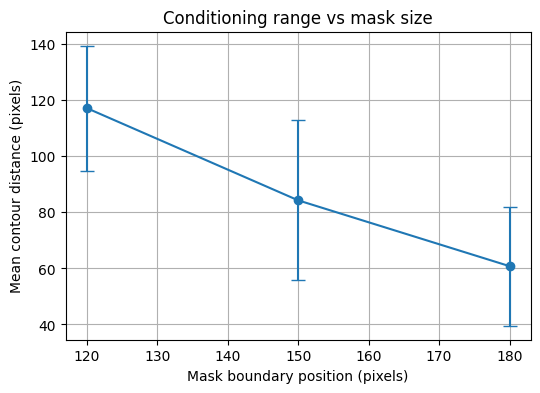

In [5]:
#Plot mask and contour distance data with error bars
import matplotlib.pyplot as plt
import numpy as np

mask_boundary = np.array([120, 150, 180])
mean_distance = np.array([117.20, 84.29, 60.80])
std_distance = np.array([22.27, 28.59, 21.26])

plt.figure(figsize=(6,4))

plt.errorbar(
    mask_boundary,
    mean_distance,
    yerr=std_distance,
    marker='o',
    capsize=5
)

plt.xlabel("Mask boundary position (pixels)")
plt.ylabel("Mean contour distance (pixels)")
plt.title("Conditioning range vs mask size")

plt.grid(True)

plt.savefig("mask_vs_distance.png", dpi=150)
plt.show()

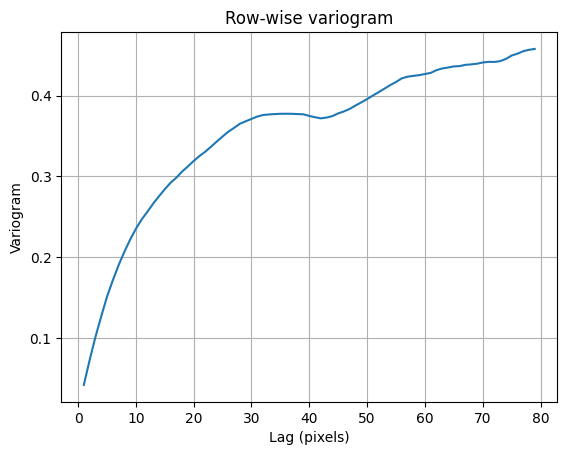

In [4]:
import numpy as np
import matplotlib.pyplot as plt

pixel_mean = np.load("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_mean_180.npy")

H, W = pixel_mean.shape

max_lag = 80

variogram = []

for lag in range(1, max_lag):

    diffs = []

    for row in range(H):

        for x in range(W - lag):

            v1 = pixel_mean[row, x]
            v2 = pixel_mean[row, x + lag]

            diffs.append((v1 - v2) ** 2)

    variogram.append(np.mean(diffs))


plt.figure()
plt.plot(range(1, max_lag), variogram)

plt.xlabel("Lag (pixels)")
plt.ylabel("Variogram")
plt.title("Row-wise variogram")

plt.grid(True)
plt.savefig("variogram.png", dpi=150)
plt.show()

/Home/siv36/hesal5042/.conda/envs/torchy/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Home/siv36/hesal5042/.conda/envs/torchy/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


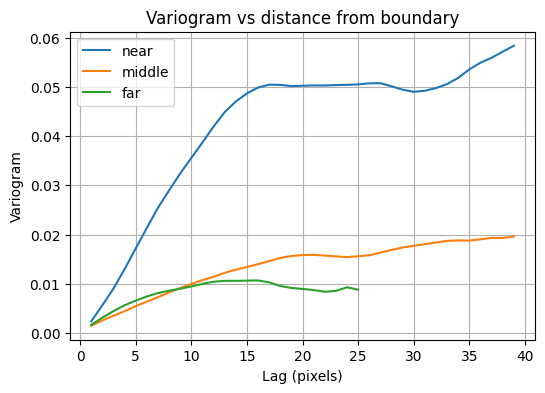

In [11]:
import numpy as np
import matplotlib.pyplot as plt

pixel_mean = np.load("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_mean_180.npy")

H, W = pixel_mean.shape

boundary = 180   # change for each mask

max_lag = 40

# regions to test
regions = {
    "near": (boundary, boundary + 20),
    "middle": (boundary + 20, boundary + 50),
    "far": (boundary + 50, boundary + 90),
}

variograms = {}

for name, (x0, x1) in regions.items():

    variogram = []

    for lag in range(1, max_lag):

        diffs = []

        for row in range(H):

            for x in range(x0, min(x1, W - lag)):

                v1 = pixel_mean[row, x]
                v2 = pixel_mean[row, x + lag]

                diffs.append((v1 - v2) ** 2)

        variogram.append(np.mean(diffs))

    variograms[name] = variogram


# plot

plt.figure(figsize=(6,4))

for name, v in variograms.items():
    plt.plot(range(1, max_lag), v, label=name)

plt.xlabel("Lag (pixels)")
plt.ylabel("Variogram")
plt.title("Variogram vs distance from boundary")
plt.legend()
plt.grid(True)
plt.savefig("variogram_by_region.png", dpi=150)
plt.show()

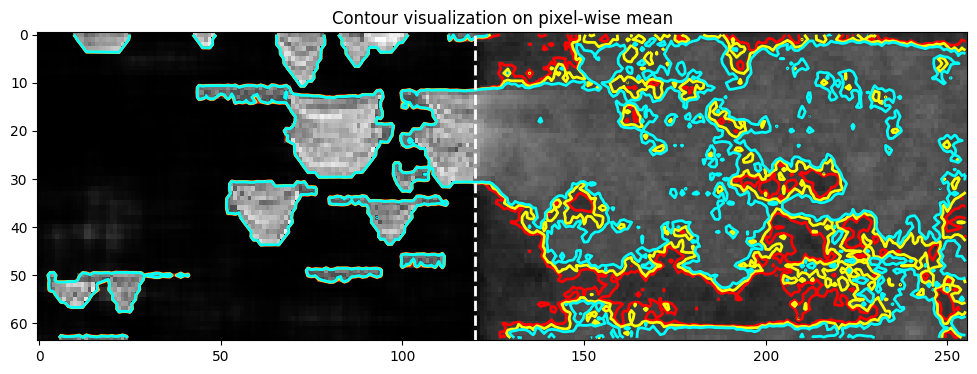

In [22]:
import numpy as np
import matplotlib.pyplot as plt

pixel_mean_120 = np.load("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_mean_120.npy")
pixel_mean = np.squeeze(pixel_mean_120)

boundary = 120
levels = [-0.55, -0.50, -0.45]

plt.figure(figsize=(12, 4))
plt.imshow(pixel_mean, cmap="gray", aspect="auto")

cs = plt.contour(pixel_mean, levels=levels, colors=["red", "yellow", "cyan"], linewidths=2)

plt.axvline(boundary, color="white", linestyle="--", linewidth=2)
plt.title("Contour visualization on pixel-wise mean")
plt.show()

In [23]:
# Check the shape and basic info
print(f"Shape of pixel_mean: {pixel_mean.shape}")
print(f"Data type: {pixel_mean.dtype}")
print(f"Value range: min={pixel_mean.min():.3f}, max={pixel_mean.max():.3f}")
print(f"Mean value: {pixel_mean.mean():.3f}")
print(f"Standard deviation: {pixel_mean.std():.3f}")

# If it's 3D (e.g., 64x256 or 256x64), we might need to squeeze
if len(pixel_mean.shape) > 2:
    pixel_mean = pixel_mean.squeeze()
    print(f"After squeezing: {pixel_mean.shape}")


# Check the shape and basic info
print(f"Shape of pixel_mean: {pixel_mean.shape}")
print(f"Value range: min={pixel_mean.min():.3f}, max={pixel_mean.max():.3f}")

# If it's 3D (e.g., 64x256 or 256x64), we might need to squeeze
if len(pixel_mean.shape) > 2:
    pixel_mean = pixel_mean.squeeze()
    print(f"After squeezing: {pixel_mean.shape}")

# Create meshgrid for your dimensions
height, width = pixel_mean.shape
X, Y = np.meshgrid(np.arange(width), np.arange(height))

# Define mask boundaries (120px mask on 256 width)
mask_start, mask_end = 68, 188

Shape of pixel_mean: (64, 256)
Data type: float32
Value range: min=-1.000, max=1.000
Mean value: -0.580
Standard deviation: 0.377
Shape of pixel_mean: (64, 256)
Value range: min=-1.000, max=1.000


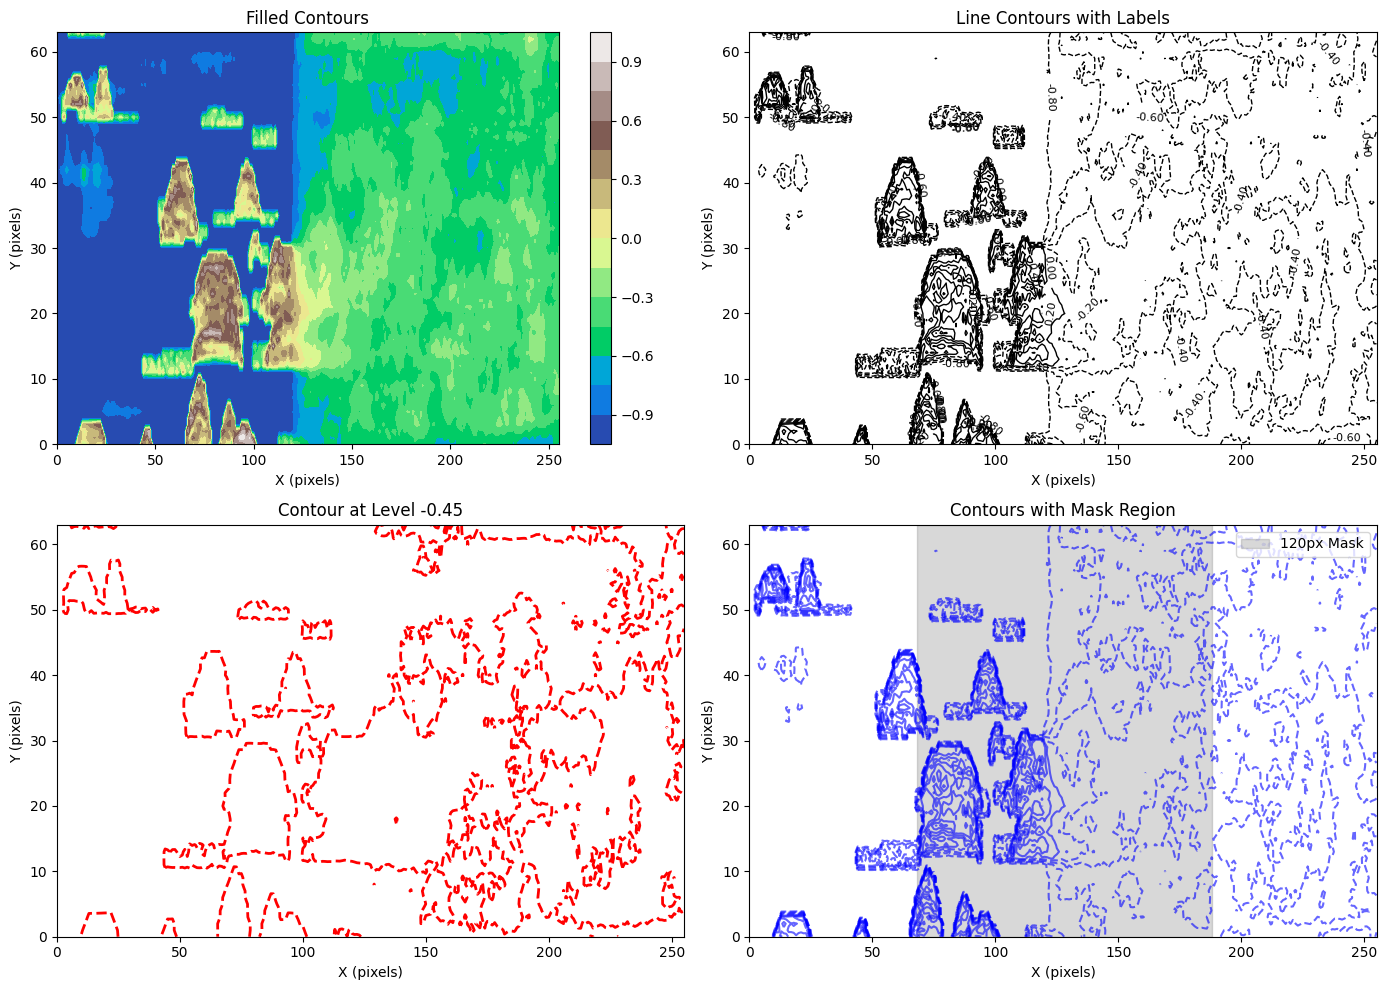

In [24]:
# Simple contour plot without trying to extract data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Filled contours
ax1 = axes[0, 0]
contour_filled = ax1.contourf(X, Y, pixel_mean, levels=15, cmap='terrain')
ax1.set_title('Filled Contours')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
plt.colorbar(contour_filled, ax=ax1)

# Plot 2: Line contours
ax2 = axes[0, 1]
contour_lines = ax2.contour(X, Y, pixel_mean, levels=10, colors='black', linewidths=1)
ax2.clabel(contour_lines, inline=True, fontsize=8, fmt='%1.2f')
ax2.set_title('Line Contours with Labels')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')

# Plot 3: Single contour at specific level
ax3 = axes[1, 0]
target_level = -0.45
single_contour = ax3.contour(X, Y, pixel_mean, levels=[target_level], colors='red', linewidths=2)
ax3.set_title(f'Contour at Level {target_level}')
ax3.set_xlabel('X (pixels)')
ax3.set_ylabel('Y (pixels)')

# Plot 4: Contour with mask
ax4 = axes[1, 1]
contour_masked = ax4.contour(X, Y, pixel_mean, levels=10, colors='blue', alpha=0.6)
ax4.axvspan(mask_start, mask_end, alpha=0.3, color='gray', label='120px Mask')
ax4.set_title('Contours with Mask Region')
ax4.set_xlabel('X (pixels)')
ax4.set_ylabel('Y (pixels)')
ax4.legend()

plt.tight_layout()
plt.show()

In [25]:
# To actually extract and quantify contour data, use this approach
def extract_contour_data(X, Y, Z, levels):
    """
    Extract contour vertices for given levels
    """
    contour_data = {}
    
    for level in levels:
        # Create contour for this level
        cs = plt.contour(X, Y, Z, levels=[level])
        
        # Extract vertices from the contour
        vertices_list = []
        # Get all segments for this level
        for seg in cs.allsegs[0]:  # allsegs[0] because we only have one level
            if len(seg) > 0:  # Check if segment has points
                vertices_list.append(seg)
        
        contour_data[level] = vertices_list
        
        # Close the plot to avoid displaying
        plt.close()
    
    return contour_data

# Extract contours at multiple levels
levels_of_interest = np.linspace(pixel_mean.min(), pixel_mean.max(), 10)
contour_data = extract_contour_data(X, Y, pixel_mean, levels_of_interest)

# Now quantify these contours
print("CONTOUR QUANTIFICATION RESULTS")
print("="*60)

for level, contours in contour_data.items():
    print(f"\nLevel {level:.3f}: {len(contours)} contour segment(s)")
    
    for i, contour in enumerate(contours):
        if len(contour) > 10:  # Only quantify meaningful contours
            # Calculate length
            length = np.sum(np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1)))
            
            # Calculate amplitude (vertical range)
            amplitude = np.ptp(contour[:, 1])
            
            # Check if contour intersects mask
            x_coords = contour[:, 0]
            in_mask = np.any((x_coords >= mask_start) & (x_coords <= mask_end))
            
            print(f"  Segment {i+1}:")
            print(f"    Length: {length:.1f} pixels")
            print(f"    Amplitude: {amplitude:.1f} pixels")
            print(f"    Points: {len(contour)}")
            print(f"    Intersects mask: {in_mask}")

CONTOUR QUANTIFICATION RESULTS

Level -1.000: 1 contour segment(s)

Level -0.778: 19 contour segment(s)
  Segment 1:
    Length: 19.6 pixels
    Amplitude: 3.9 pixels
    Points: 24
    Intersects mask: False
  Segment 2:
    Length: 9.8 pixels
    Amplitude: 2.9 pixels
    Points: 12
    Intersects mask: False
  Segment 3:
    Length: 28.6 pixels
    Amplitude: 10.9 pixels
    Points: 35
    Intersects mask: True
  Segment 4:
    Length: 27.9 pixels
    Amplitude: 6.8 pixels
    Points: 35
    Intersects mask: True
  Segment 5:
    Length: 20.2 pixels
    Amplitude: 0.8 pixels
    Points: 21
    Intersects mask: False
  Segment 6:
    Length: 164.8 pixels
    Amplitude: 63.0 pixels
    Points: 196
    Intersects mask: True
  Segment 7:
    Length: 146.1 pixels
    Amplitude: 19.7 pixels
    Points: 161
    Intersects mask: True
  Segment 8:
    Length: 69.8 pixels
    Amplitude: 13.7 pixels
    Points: 79
    Intersects mask: True
  Segment 9:
    Length: 80.3 pixels
    Amplitude: 10

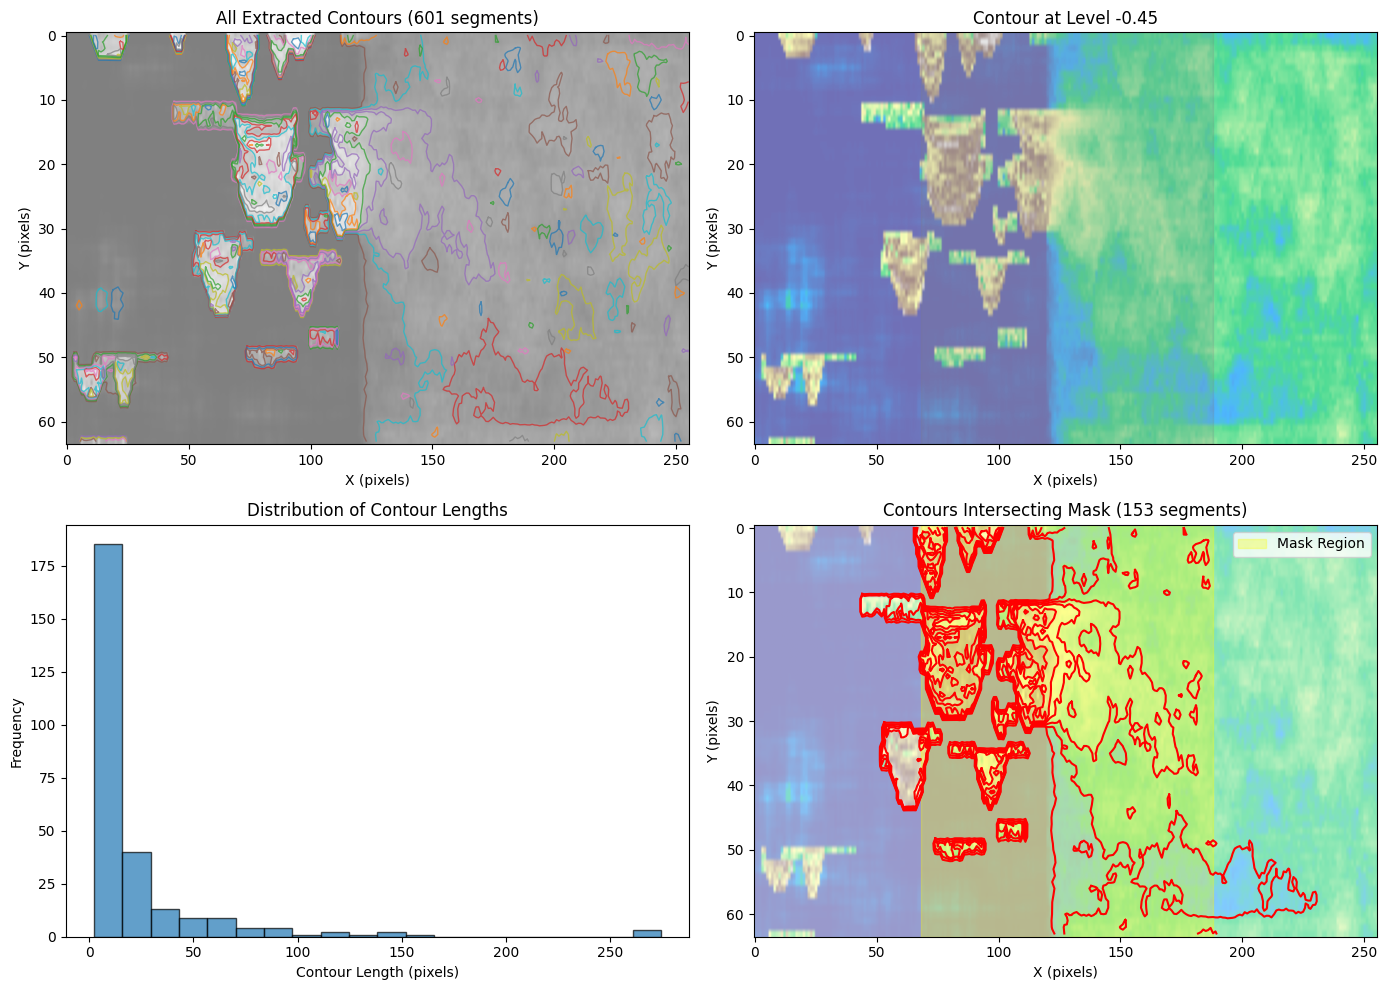


Found 153 contour segments that intersect the mask region


In [26]:
# Create a figure to visualize the extracted contours
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Show all extracted contours
ax1 = axes[0, 0]
ax1.imshow(pixel_mean, cmap='gray', aspect='auto', origin='upper', alpha=0.5)
for level, contours in contour_data.items():
    for contour in contours:
        if len(contour) > 5:
            ax1.plot(contour[:, 0], contour[:, 1], linewidth=1, alpha=0.7)
ax1.set_title(f'All Extracted Contours ({sum(len(c) for c in contour_data.values())} segments)')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')

# Plot 2: Highlight specific level
ax2 = axes[0, 1]
ax2.imshow(pixel_mean, cmap='terrain', aspect='auto', origin='upper', alpha=0.7)
target_level = -0.45
if target_level in contour_data:
    for contour in contour_data[target_level]:
        if len(contour) > 5:
            ax2.plot(contour[:, 0], contour[:, 1], 'r-', linewidth=2, label=f'Level {target_level}')
ax2.axvspan(mask_start, mask_end, alpha=0.2, color='gray')
ax2.set_title(f'Contour at Level {target_level}')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')

# Plot 3: Contour length distribution
ax3 = axes[1, 0]
all_lengths = []
for level, contours in contour_data.items():
    for contour in contours:
        if len(contour) > 5:
            length = np.sum(np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1)))
            all_lengths.append(length)

ax3.hist(all_lengths, bins=20, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Contour Length (pixels)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Contour Lengths')

# Plot 4: Contours that intersect the mask
ax4 = axes[1, 1]
ax4.imshow(pixel_mean, cmap='terrain', aspect='auto', origin='upper', alpha=0.5)
ax4.axvspan(mask_start, mask_end, alpha=0.3, color='yellow', label='Mask Region')

mask_contours = []
for level, contours in contour_data.items():
    for contour in contours:
        if len(contour) > 5:
            x_coords = contour[:, 0]
            if np.any((x_coords >= mask_start) & (x_coords <= mask_end)):
                ax4.plot(contour[:, 0], contour[:, 1], 'r-', linewidth=1.5)
                mask_contours.append(contour)

ax4.set_title(f'Contours Intersecting Mask ({len(mask_contours)} segments)')
ax4.set_xlabel('X (pixels)')
ax4.set_ylabel('Y (pixels)')
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\nFound {len(mask_contours)} contour segments that intersect the mask region")

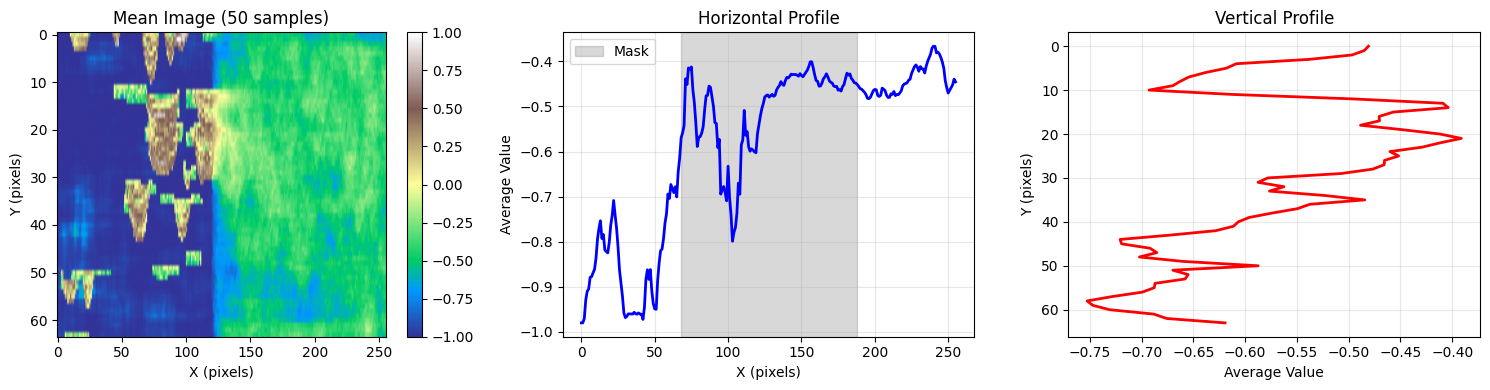


BASIC STATISTICS OF MEAN IMAGE
Shape: (64, 256)
Min value: -1.0000
Max value: 1.0000
Mean value: -0.5800
Std deviation: 0.3766
25th percentile: -0.9727
50th percentile (median): -0.5326
75th percentile: -0.3816

STATISTICS WITHIN MASK (columns 68-188)
Min in mask: -1.0000
Max in mask: 1.0000
Mean in mask: -0.5054
Std in mask: 0.4110


In [27]:
# Quick statistical summary of your mean image
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: The mean image
ax1 = axes[0]
im = ax1.imshow(pixel_mean, cmap='terrain', aspect='auto', origin='upper')
ax1.set_title('Mean Image (50 samples)')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
plt.colorbar(im, ax=ax1)

# Plot 2: Horizontal profile (average across rows)
ax2 = axes[1]
horizontal_profile = np.mean(pixel_mean, axis=0)
x_axis = np.arange(width)
ax2.plot(x_axis, horizontal_profile, 'b-', linewidth=2)
ax2.axvspan(mask_start, mask_end, alpha=0.3, color='gray', label='Mask')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Average Value')
ax2.set_title('Horizontal Profile')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Vertical profile (average across columns)
ax3 = axes[2]
vertical_profile = np.mean(pixel_mean, axis=1)
y_axis = np.arange(height)
ax3.plot(vertical_profile, y_axis, 'r-', linewidth=2)
ax3.set_xlabel('Average Value')
ax3.set_ylabel('Y (pixels)')
ax3.set_title('Vertical Profile')
ax3.invert_yaxis()  # So depth increases downward
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS OF MEAN IMAGE")
print("="*50)
print(f"Shape: {pixel_mean.shape}")
print(f"Min value: {pixel_mean.min():.4f}")
print(f"Max value: {pixel_mean.max():.4f}")
print(f"Mean value: {pixel_mean.mean():.4f}")
print(f"Std deviation: {pixel_mean.std():.4f}")
print(f"25th percentile: {np.percentile(pixel_mean, 25):.4f}")
print(f"50th percentile (median): {np.percentile(pixel_mean, 50):.4f}")
print(f"75th percentile: {np.percentile(pixel_mean, 75):.4f}")

# Statistics within mask region
mask_region = pixel_mean[:, mask_start:mask_end]
print(f"\nSTATISTICS WITHIN MASK (columns {mask_start}-{mask_end})")
print(f"Min in mask: {mask_region.min():.4f}")
print(f"Max in mask: {mask_region.max():.4f}")
print(f"Mean in mask: {mask_region.mean():.4f}")
print(f"Std in mask: {mask_region.std():.4f}")

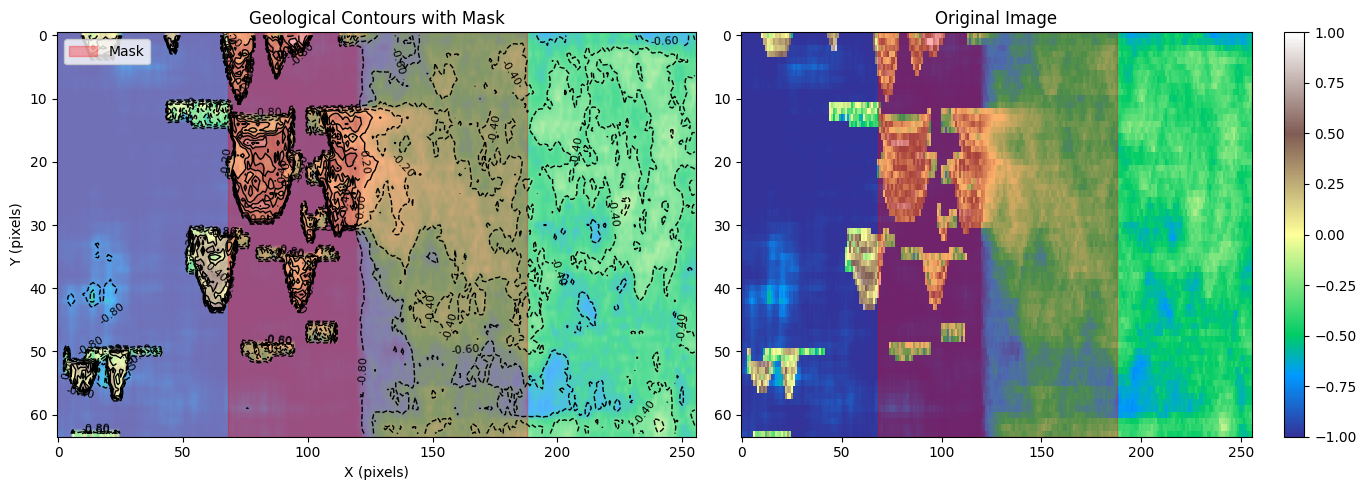


SIMPLE CONTOUR ANALYSIS

Total contours found: 114
Contours intersecting mask: 68
Percentage intersecting: 59.6%

Contour lengths:
  Mean: 38.8 pixels
  Std: 68.5 pixels
  Min: 5.5 pixels
  Max: 560.5 pixels

MASK REGION STATISTICS:
  Inside mask - Mean: -0.505, Std: 0.411
  Outside mask - Mean: -0.646, Std: 0.330
  Difference: 0.141


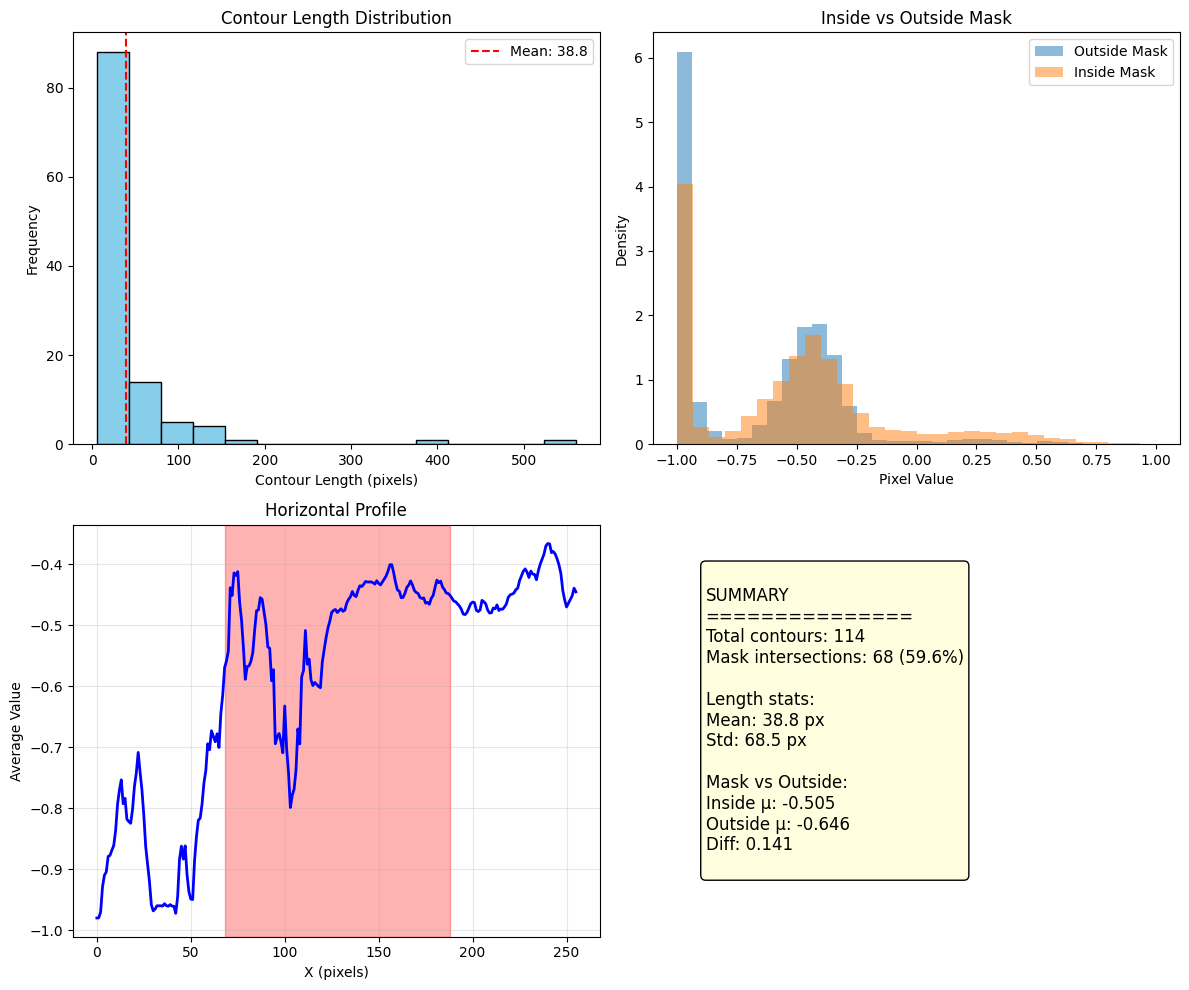

In [28]:
import numpy as np
import matplotlib.pyplot as plt

if len(pixel_mean.shape) > 2:
    pixel_mean = pixel_mean.squeeze()

height, width = pixel_mean.shape
X, Y = np.meshgrid(np.arange(width), np.arange(height))
mask_start, mask_end = 68, 188

# 1. SIMPLE CONTOUR PLOT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot with contours
ax1.imshow(pixel_mean, cmap='terrain', aspect='auto', origin='upper', alpha=0.7)
contour = ax1.contour(X, Y, pixel_mean, levels=10, colors='black', linewidths=1)
ax1.clabel(contour, inline=True, fontsize=8, fmt='%1.2f')
ax1.axvspan(mask_start, mask_end, alpha=0.3, color='red', label='Mask')
ax1.set_title('Geological Contours with Mask')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax1.legend()

# Plot with colorbar
im = ax2.imshow(pixel_mean, cmap='terrain', aspect='auto', origin='upper')
ax2.axvspan(mask_start, mask_end, alpha=0.3, color='red')
ax2.set_title('Original Image')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

# 2. EXTRACT AND ANALYZE CONTOURS
print("\n" + "="*50)
print("SIMPLE CONTOUR ANALYSIS")
print("="*50)

# Choose a few levels to analyze
levels = np.linspace(pixel_mean.min(), pixel_mean.max(), 8)
all_lengths = []
mask_intersections = 0
total_contours = 0

for level in levels:
    cs = plt.contour(X, Y, pixel_mean, levels=[level])
    
    for segment in cs.allsegs[0]:
        if len(segment) > 10:  # Only meaningful contours
            total_contours += 1
            
            # Calculate length
            length = np.sum(np.sqrt(np.sum(np.diff(segment, axis=0)**2, axis=1)))
            all_lengths.append(length)
            
            # Check if intersects mask
            x_coords = segment[:, 0]
            if np.any((x_coords >= mask_start) & (x_coords <= mask_end)):
                mask_intersections += 1
                
    plt.close()

# Print simple statistics
print(f"\nTotal contours found: {total_contours}")
print(f"Contours intersecting mask: {mask_intersections}")
print(f"Percentage intersecting: {mask_intersections/total_contours*100:.1f}%")
print(f"\nContour lengths:")
print(f"  Mean: {np.mean(all_lengths):.1f} pixels")
print(f"  Std: {np.std(all_lengths):.1f} pixels")
print(f"  Min: {np.min(all_lengths):.1f} pixels")
print(f"  Max: {np.max(all_lengths):.1f} pixels")

# 3. QUICK MASK VS OUTSIDE COMPARISON
inside_mask = pixel_mean[:, mask_start:mask_end].flatten()
outside_mask = np.concatenate([pixel_mean[:, :mask_start].flatten(), 
                               pixel_mean[:, mask_end:].flatten()])

print(f"\nMASK REGION STATISTICS:")
print(f"  Inside mask - Mean: {inside_mask.mean():.3f}, Std: {inside_mask.std():.3f}")
print(f"  Outside mask - Mean: {outside_mask.mean():.3f}, Std: {outside_mask.std():.3f}")
print(f"  Difference: {inside_mask.mean() - outside_mask.mean():.3f}")

# 4. SIMPLE VISUAL SUMMARY
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Contour length histogram
axes[0, 0].hist(all_lengths, bins=15, edgecolor='black', color='skyblue')
axes[0, 0].set_xlabel('Contour Length (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Contour Length Distribution')
axes[0, 0].axvline(np.mean(all_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(all_lengths):.1f}')
axes[0, 0].legend()

# Inside vs outside mask comparison
axes[0, 1].hist(outside_mask, bins=30, alpha=0.5, label='Outside Mask', density=True)
axes[0, 1].hist(inside_mask, bins=30, alpha=0.5, label='Inside Mask', density=True)
axes[0, 1].set_xlabel('Pixel Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Inside vs Outside Mask')
axes[0, 1].legend()

# Horizontal profile
horizontal_profile = np.mean(pixel_mean, axis=0)
axes[1, 0].plot(horizontal_profile, 'b-', linewidth=2)
axes[1, 0].axvspan(mask_start, mask_end, alpha=0.3, color='red')
axes[1, 0].set_xlabel('X (pixels)')
axes[1, 0].set_ylabel('Average Value')
axes[1, 0].set_title('Horizontal Profile')
axes[1, 0].grid(True, alpha=0.3)

# Summary text
axes[1, 1].axis('off')
summary = f"""
SUMMARY
===============
Total contours: {total_contours}
Mask intersections: {mask_intersections} ({mask_intersections/total_contours*100:.1f}%)

Length stats:
Mean: {np.mean(all_lengths):.1f} px
Std: {np.std(all_lengths):.1f} px

Mask vs Outside:
Inside μ: {inside_mask.mean():.3f}
Outside μ: {outside_mask.mean():.3f}
Diff: {inside_mask.mean() - outside_mask.mean():.3f}
"""
axes[1, 1].text(0.1, 0.9, summary, transform=axes[1, 1].transAxes, 
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

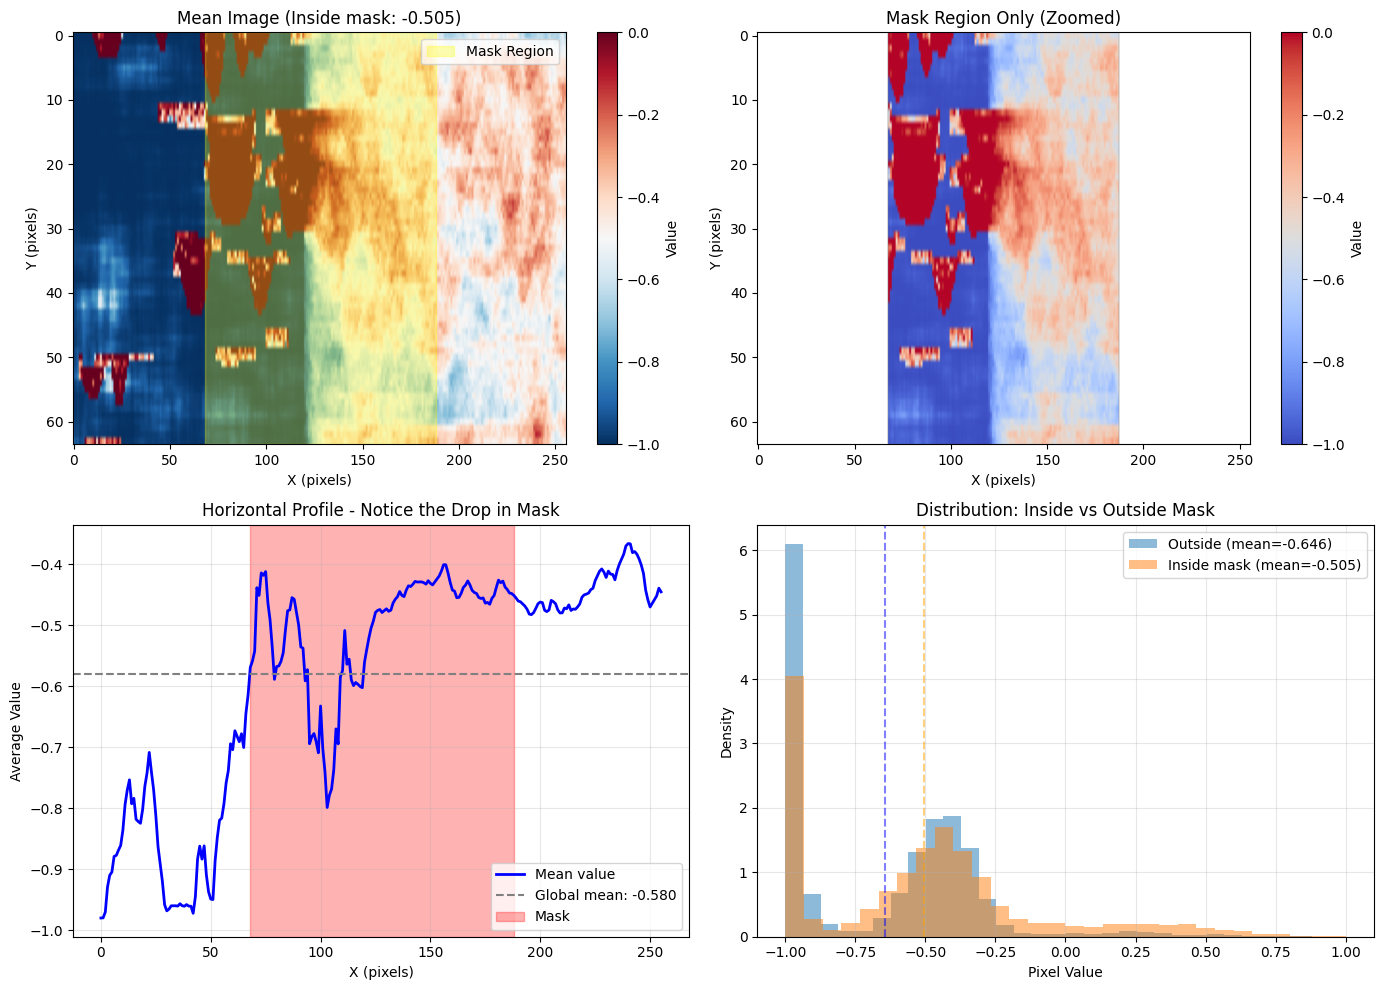


INTERPRETATION OF YOUR RESULTS

The mask region has values that are 0.141 units LOWER
than the surrounding area (-0.505 vs -0.646)

The mask region matches the surroundings well.

STATISTICAL SIGNIFICANCE:
T-statistic: 24.260
P-value: 0.0000
✓ The difference IS statistically significant (p < 0.05)
  The mask region is genuinely different from surroundings


In [29]:
# Simple t-test to see if the difference is statistically significant
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

if len(pixel_mean.shape) > 2:
    pixel_mean = pixel_mean.squeeze()

height, width = pixel_mean.shape
mask_start, mask_end = 68, 188

# Create a simple but informative plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Show the mean image with mask
ax1 = axes[0, 0]
im = ax1.imshow(pixel_mean, cmap='RdBu_r', aspect='auto', origin='upper', 
                vmin=-1, vmax=0)  # Focus on your value range
ax1.axvspan(mask_start, mask_end, alpha=0.3, color='yellow', label='Mask Region')
ax1.set_title(f'Mean Image (Inside mask: {pixel_mean[:, mask_start:mask_end].mean():.3f})')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax1.legend()
plt.colorbar(im, ax=ax1, label='Value')

# 2. Show the difference clearly
ax2 = axes[0, 1]
# Create a difference map
diff_map = pixel_mean.copy()
diff_map[:, :mask_start] = np.nan
diff_map[:, mask_end:] = np.nan
im2 = ax2.imshow(diff_map, cmap='coolwarm', aspect='auto', origin='upper',
                 vmin=-1, vmax=0)
ax2.set_title('Mask Region Only (Zoomed)')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')
plt.colorbar(im2, ax=ax2, label='Value')

# 3. Horizontal profile showing the drop
ax3 = axes[1, 0]
horizontal_profile = np.mean(pixel_mean, axis=0)
x_axis = np.arange(width)
ax3.plot(x_axis, horizontal_profile, 'b-', linewidth=2, label='Mean value')
ax3.axhline(y=pixel_mean.mean(), color='gray', linestyle='--', label=f'Global mean: {pixel_mean.mean():.3f}')
ax3.axvspan(mask_start, mask_end, alpha=0.3, color='red', label='Mask')
ax3.set_xlabel('X (pixels)')
ax3.set_ylabel('Average Value')
ax3.set_title('Horizontal Profile - Notice the Drop in Mask')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Value distribution comparison
ax4 = axes[1, 1]
inside = pixel_mean[:, mask_start:mask_end].flatten()
outside = np.concatenate([pixel_mean[:, :mask_start].flatten(), 
                          pixel_mean[:, mask_end:].flatten()])

ax4.hist(outside, bins=30, alpha=0.5, label=f'Outside (mean={outside.mean():.3f})', density=True)
ax4.hist(inside, bins=30, alpha=0.5, label=f'Inside mask (mean={inside.mean():.3f})', density=True)
ax4.axvline(x=outside.mean(), color='blue', linestyle='--', alpha=0.5)
ax4.axvline(x=inside.mean(), color='orange', linestyle='--', alpha=0.5)
ax4.set_xlabel('Pixel Value')
ax4.set_ylabel('Density')
ax4.set_title('Distribution: Inside vs Outside Mask')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Simple interpretation
print("\n" + "="*60)
print("INTERPRETATION OF YOUR RESULTS")
print("="*60)
print(f"\nThe mask region has values that are {abs(inside.mean() - outside.mean()):.3f} units LOWER")
print(f"than the surrounding area ({inside.mean():.3f} vs {outside.mean():.3f})")

if inside.mean() < outside.mean():
    print("\nThis suggests the diffusion model reconstructed a")
    print("geological feature that is DIFFERENT from the surroundings.")
    print("Possible interpretations:")
    print("  • A different rock type in the mask region")
    print("  • A structural low (syncline or basin)")
    print("  • A fault-bounded block with different properties")
else:
    print("\nThe mask region matches the surroundings well.")

t_stat, p_value = stats.ttest_ind(inside, outside)
print(f"\nSTATISTICAL SIGNIFICANCE:")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✓ The difference IS statistically significant (p < 0.05)")
    print("  The mask region is genuinely different from surroundings")
else:
    print("✗ The difference is NOT statistically significant")
    print("  The mask region is similar to surroundings")

/tmp/ipykernel_2858767/439912524.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


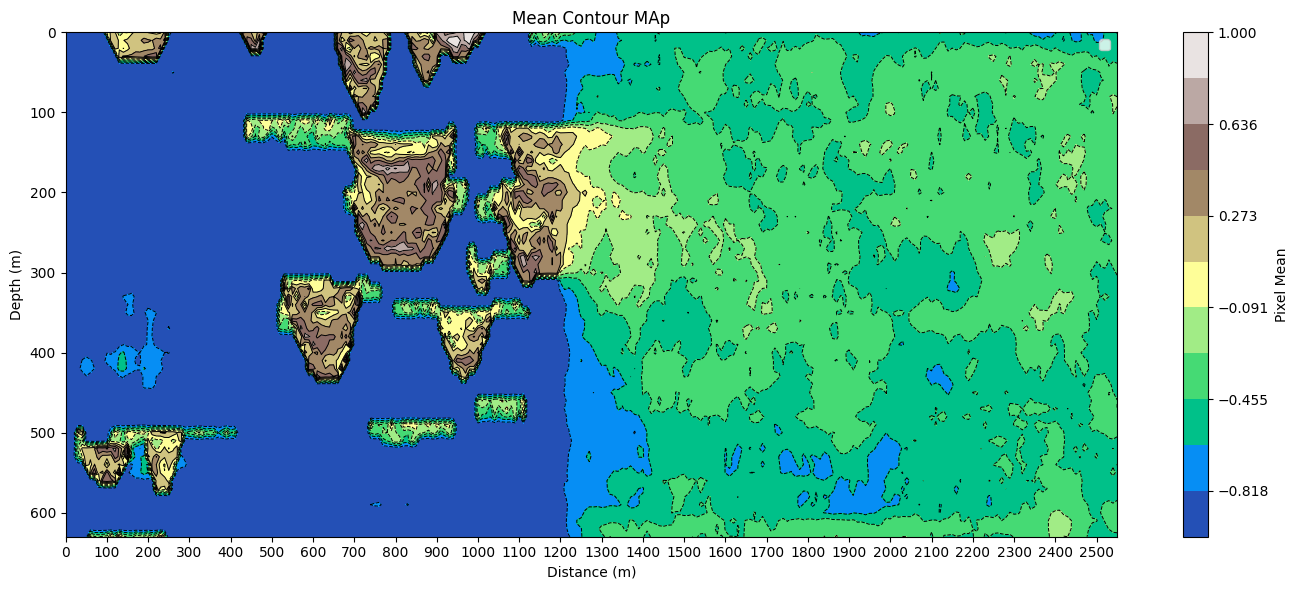

In [28]:
import numpy as np
import matplotlib.pyplot as plt

pixel_mean_180 = np.load("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_mean_120.npy")
pixel_mean = np.squeeze(pixel_mean_180)

H, W = pixel_mean.shape
x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

levels = np.linspace(pixel_mean.min(), pixel_mean.max(), 12)

fig, ax = plt.subplots(figsize=(14, 6))

# filled contour map
cf = ax.contourf(X, Y, pixel_mean, levels=levels, cmap="terrain")

# contour lines
cs = ax.contour(X, Y, pixel_mean, levels=levels, colors="black", linewidths=0.7)
xticks = np.arange(0, W, 10)
yticks = np.arange(0, H, 10)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels(xticks * 10)
ax.set_yticklabels(yticks * 10)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

ax.invert_yaxis()
ax.set_title("Mean Contour MAp")
ax.legend()

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel Mean")

plt.tight_layout()
plt.savefig("mean_contour.png", dpi=300, bbox_inches="tight")
plt.show()
# contour labels
# ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

# ax.invert_yaxis()
# ax.set_title("Pixel Mean Contour Map")
# ax.set_xlabel("X (pixels)")
# ax.set_ylabel("Z (pixels)")

# cbar = fig.colorbar(cf, ax=ax)
# cbar.set_label("Pixel mean")

# plt.tight_layout()
# plt.savefig("pixel_mean_contour_map.png", dpi=200, bbox_inches="tight")
plt.show()

## Contour Map

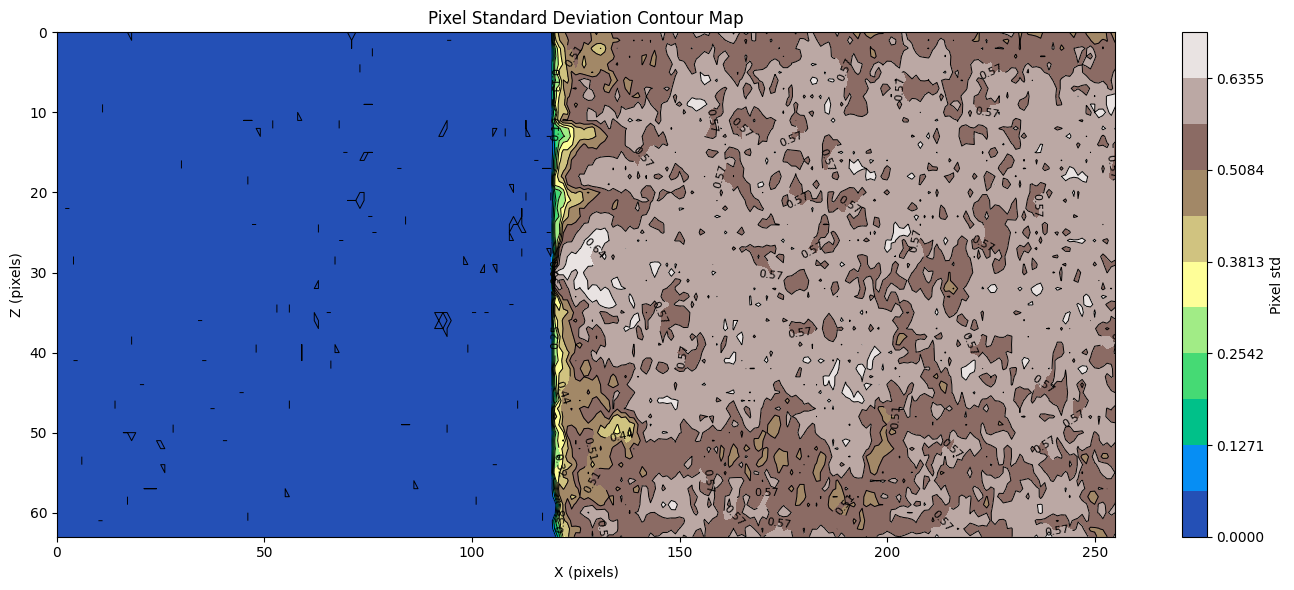

In [3]:
import numpy as np
import matplotlib.pyplot as plt

pixel_std_180 = np.load("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_std_120.npy")
pixel_std = np.squeeze(pixel_std_180)

H, W = pixel_std.shape
x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

levels = np.linspace(pixel_std.min(), pixel_std.max(), 12)

fig, ax = plt.subplots(figsize=(14, 6))

# filled contour map
cf = ax.contourf(X, Y, pixel_std, levels=levels, cmap="terrain")

# contour lines
cs = ax.contour(X, Y, pixel_std, levels=levels, colors="black", linewidths=0.7)

# contour labels
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.invert_yaxis()
ax.set_title("Pixel Standard Deviation Contour Map")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Z (pixels)")

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel std")

plt.tight_layout()
# plt.savefig("pixel_mean_contour_map.png", dpi=200, bbox_inches="tight")
plt.show()

/tmp/ipykernel_2782202/2432444760.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


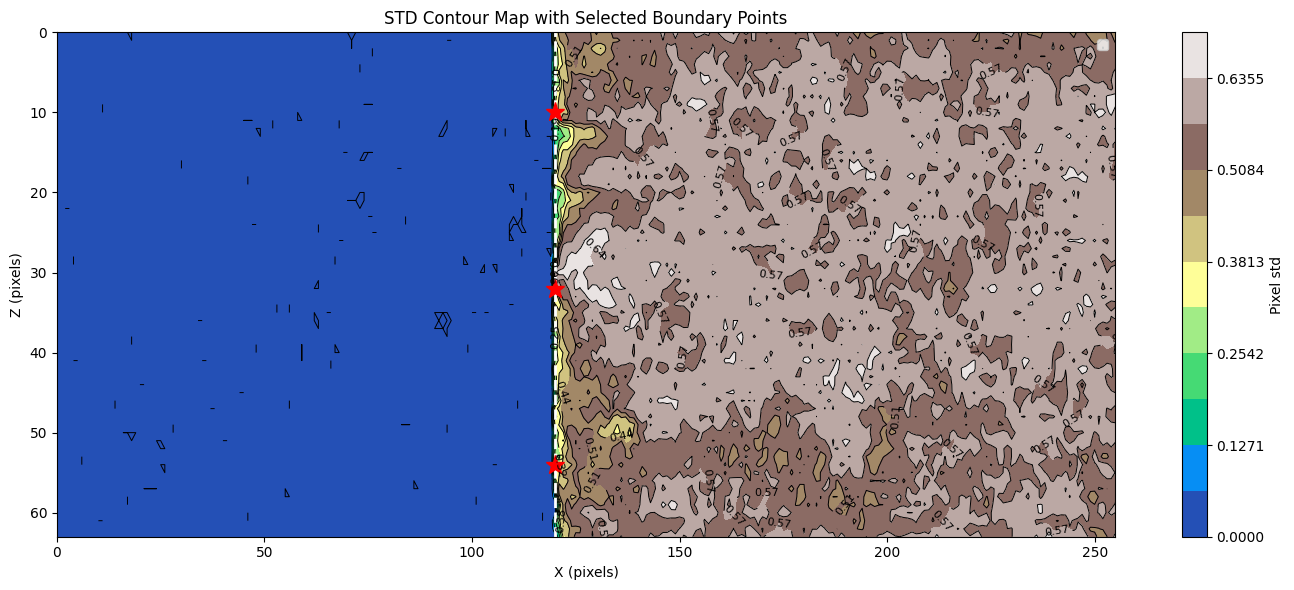

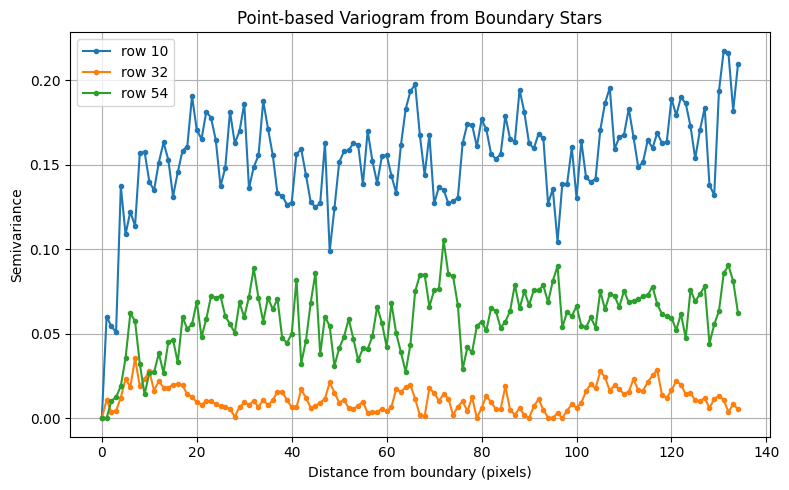

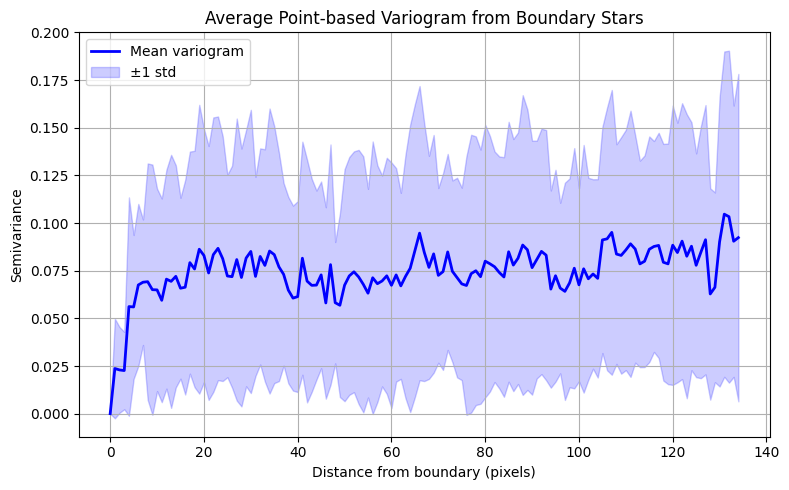

Selected star rows: [10, 32, 54]
Boundary column: 120

STD value at each star:
  row 10: 0.1954
  row 32: 0.4955
  row 54: 0.3023

Mean semivariance at final lag: 0.092339955


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load STD field
# --------------------------------------------------
pixel_std = np.load(
    "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_std_120.npy"
)
pixel_std = np.squeeze(pixel_std)

H, W = pixel_std.shape
x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

# --------------------------------------------------
# Boundary position
# --------------------------------------------------
boundary = 120   # change to 150 or 180 for other masks

# --------------------------------------------------
# Choose 3 boundary points (top, middle, bottom)
# Avoid very edges to reduce artifacts
# --------------------------------------------------
points_y = [10, H // 2, H - 10]
points_x = [boundary] * len(points_y)

# --------------------------------------------------
# Plot contour map with stars
# --------------------------------------------------
levels = np.linspace(pixel_std.min(), pixel_std.max(), 12)

fig, ax = plt.subplots(figsize=(14, 6))

# Filled contours
cf = ax.contourf(X, Y, pixel_std, levels=levels, cmap="terrain")

# Contour lines
cs = ax.contour(X, Y, pixel_std, levels=levels, colors="black", linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

# Mask boundary
ax.axvline(boundary, color="white", linestyle="--", linewidth=2)

# Stars on boundary
ax.plot(points_x, points_y, "*", color="red", markersize=14)

ax.invert_yaxis()
ax.set_title("STD Contour Map with Selected Boundary Points")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Z (pixels)")
ax.legend()

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel std")

plt.tight_layout()
plt.savefig("std_contour_with_stars.png", dpi=200, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# Point-based variogram from each star
# --------------------------------------------------
max_lag = W - boundary - 1
lags = np.arange(0, max_lag)

variograms = {}

for py in points_y:
    z0 = pixel_std[py, boundary]

    gamma = []
    for h in lags:
        zh = pixel_std[py, boundary + h]
        gamma.append((zh - z0) ** 2)

    variograms[py] = np.array(gamma)

# --------------------------------------------------
# Plot variogram for each star
# --------------------------------------------------
plt.figure(figsize=(8, 5))

for py, gamma in variograms.items():
    plt.plot(lags, gamma, marker='o', markersize=3, label=f"row {py}")

plt.xlabel("Distance from boundary (pixels)")
plt.ylabel("Semivariance")
plt.title("Point-based Variogram from Boundary Stars")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("variogram_from_stars.png", dpi=200, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# Mean variogram across stars
# --------------------------------------------------
all_gamma = np.stack(list(variograms.values()), axis=0)
mean_gamma = np.mean(all_gamma, axis=0)
std_gamma = np.std(all_gamma, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(lags, mean_gamma, color="blue", linewidth=2, label="Mean variogram")
plt.fill_between(
    lags,
    mean_gamma - std_gamma,
    mean_gamma + std_gamma,
    color="blue",
    alpha=0.2,
    label="±1 std"
)
plt.xlabel("Distance from boundary (pixels)")
plt.ylabel("Semivariance")
plt.title("Average Point-based Variogram from Boundary Stars")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("mean_variogram_from_stars.png", dpi=200, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# Print summary
# --------------------------------------------------
print("Selected star rows:", points_y)
print("Boundary column:", boundary)
print("\nSTD value at each star:")
for py in points_y:
    print(f"  row {py}: {pixel_std[py, boundary]:.4f}")

print("\nMean semivariance at final lag:", mean_gamma[-1])

/tmp/ipykernel_3732904/3588960185.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


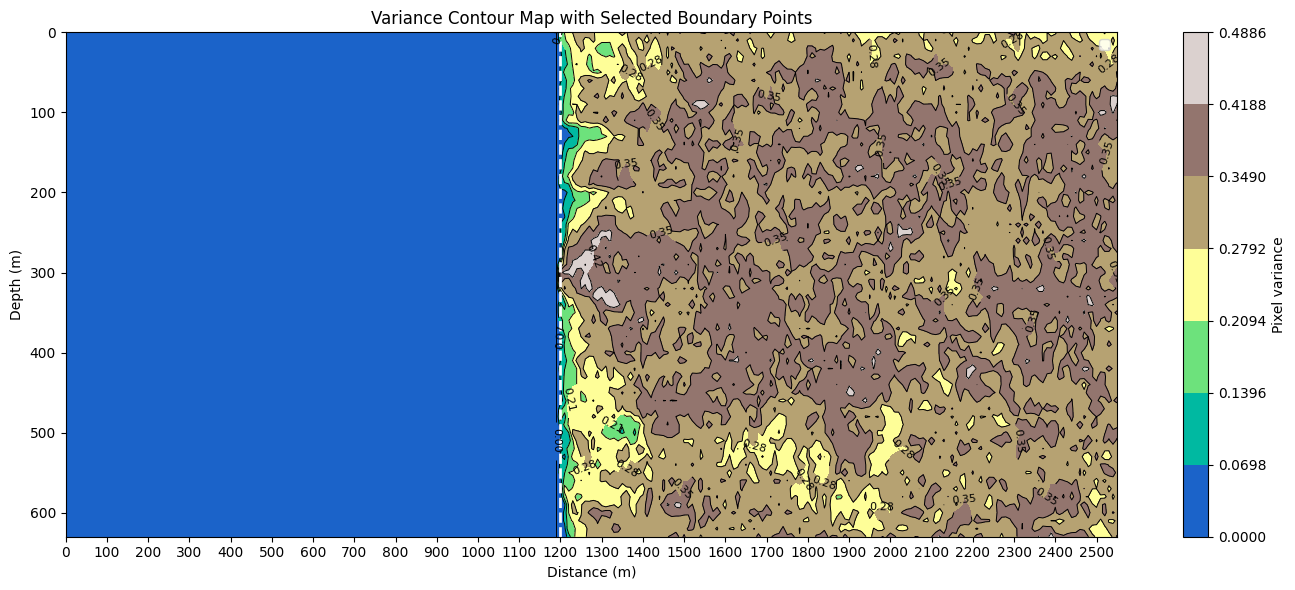

Selected star rows: [10, 32, 54]
Boundary column: 120

STD value at each star:
  row 10: 0.0382
  row 32: 0.2455
  row 54: 0.0914

Mean semivariance at final lag: 0.014375412


In [7]:
import numpy as np
import matplotlib.pyplot as plt

pixel_std = np.load(
    "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_std_120.npy"
)
pixel_std = np.squeeze(pixel_std)
pixel_std = pixel_std**2 #convertig to variance
pixel_std[pixel_std < 1e-8] = 0 #avoiding numerical issues
#variance is zero but before the contour was showing line for tiny floating-point differences

H, W = pixel_std.shape



x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

boundary = 120   #150 or 180

#coundaries
points_y = [10, H // 2, H - 10]
points_x = [boundary] * len(points_y)

levels = np.linspace(pixel_std.min(), pixel_std.max(), 8)

fig, ax = plt.subplots(figsize=(14, 6))
cf = ax.contourf(X, Y, pixel_std, levels=levels, cmap="terrain")
cs = ax.contour(X, Y, pixel_std, levels=levels, colors="black", linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.axvline(boundary, color="white", linestyle="--", linewidth=2)

# ax.plot(points_x, points_y, "*", color="red", markersize=14)
xticks = np.arange(0, W, 10)
yticks = np.arange(0, H, 10)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels(xticks * 10)
ax.set_yticklabels(yticks * 10)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

ax.invert_yaxis()
ax.set_title("Variance Contour Map with Selected Boundary Points")
ax.legend()

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel variance")

plt.tight_layout()
plt.savefig("variance_contour_with_stars_meters.png", dpi=300, bbox_inches="tight")
plt.show()


#variogram for each star
max_lag = W - boundary - 5  
lags = np.arange(1, max_lag)
half_window = 4  # to average over a small window around the star
data = pixel_std[:, boundary:]
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # window of rows around the selected point
    window = data[y0:y1, :]   # shape: (n_rows, n_cols)

    gamma = []

    for h in lags:
        if h == 0:
            continue
        diffs = []

        for r in range(window.shape[0]):
            row = window[r, :]

            # all pairs separated by lag h
            d = row[h:] - row[:-h]
            diffs.extend(d ** 2)

        # semivariance = 0.5 * mean squared difference
        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)

# plt.xlabel("Distance from boundary (pixels)")
# plt.ylabel("Semivariance")
# plt.title("Point-based Variogram from Boundary Stars")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.savefig("variogram_from_stars.png", dpi=300, bbox_inches="tight")
# plt.show()
# all_gamma = np.stack(list(variograms.values()), axis=0)
# mean_gamma = np.mean(all_gamma, axis=0)
# std_gamma = np.std(all_gamma, axis=0)

# plt.figure(figsize=(8, 5))
# plt.plot(lags, mean_gamma, color="blue", linewidth=2, label="Mean variogram")
# plt.fill_between(
#     lags,
#     mean_gamma - std_gamma,
#     mean_gamma + std_gamma,
#     color="blue",
#     alpha=0.2,
#     label="±1 std"
# )
# plt.xlabel("Distance from boundary (pixels)")
# plt.ylabel("Semivariance")
# plt.title("Average Point-based Variogram from Boundary Stars")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.savefig("mean_variogram_from_stars.png", dpi=200, bbox_inches="tight")
# plt.show()

print("Selected star rows:", points_y)
print("Boundary column:", boundary)
print("\nSTD value at each star:")
for py in points_y:
    print(f"  row {py}: {pixel_std[py, boundary]:.4f}")

print("\nMean semivariance at final lag:", mean_gamma[-1])


## Variograms

In [ ]:
#checking the shape of one realization
r = np.load("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/trial/50/repaint_sample_000.npy")
print(r.shape)

(1, 1, 64, 256)


In [ ]:
#checking the shape of one realization
r = np.load("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/trial/50/repaint_sample_000.npy")
print(r.shape)
import glob
files = glob.glob("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/trial/50/repaint_sample_*.npy")
samples = np.stack([np.load(f) for f in files], axis=0)
samples = np.squeeze(samples) #remove any extra dimensions if they exist
print(samples.shape)
N, H, W = samples.shape


Row 10
Empirical variance: 0.3507
Estimated sill: 0.3564
Ratio: 1.016

Row 32
Empirical variance: 0.3656
Estimated sill: 0.3966
Ratio: 1.085

Row 54
Empirical variance: 0.3110
Estimated sill: 0.3056
Ratio: 0.983


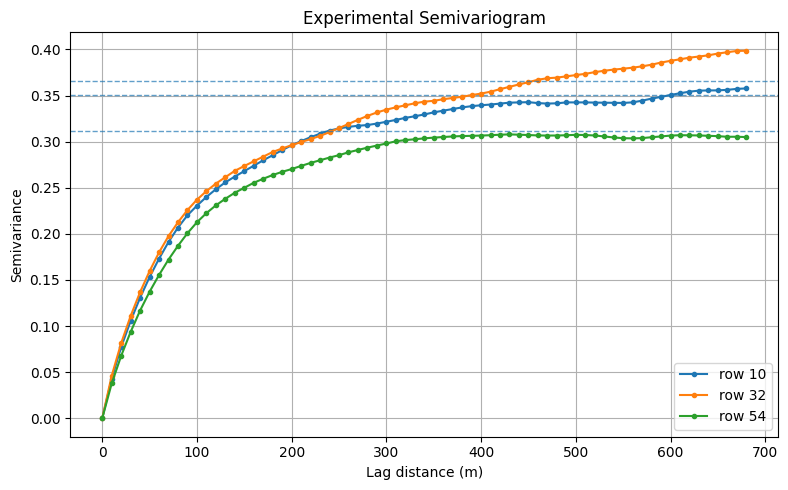

In [21]:
boundary = 120
points_y = [10, 32, 54]
half_window = 4
pixel_size_m = 10

# only use region to the right of boundary
samples_right = samples[:, :, boundary:]   # shape: (N, H, W_right)

# choose moderate lags
# max_lag = min(60, samples_right.shape[2] - 1)
max_lag = samples_right.shape[2] //2
lags = np.arange(0, max_lag + 1)

variograms = {}
empirical_vars = {}
pair_counts = {}

# --------------------------------------------------
# Experimental semivariogram:
# gamma(h) = 0.5 * mean[(Z(x+h) - Z(x))^2]
# --------------------------------------------------
for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # shape: (N, n_rows, n_cols)
    window = samples_right[:, y0:y1, :]

    gamma = []
    counts = []

    # empirical variance in this window
    empirical_vars[py] = np.var(window)

    for h in lags:
        if h == 0:
            gamma.append(0.0)
            counts.append(window.size)
            continue

        left = window[:, :, :-h]
        right = window[:, :, h:]

        diffs = right - left
        gamma.append(0.5 * np.mean(diffs ** 2))
        counts.append(diffs.size)

    variograms[py] = np.array(gamma)
    pair_counts[py] = np.array(counts)

# --------------------------------------------------
# Plot semivariogram for each selected row window
# --------------------------------------------------
plt.figure(figsize=(8, 5))
for py, gamma in variograms.items():
    sill_estimate = np.mean(gamma[-5:])
    var = empirical_vars[py]

    print(f"\nRow {py}")
    print(f"Empirical variance: {var:.4f}")
    print(f"Estimated sill: {sill_estimate:.4f}")
    print(f"Ratio: {sill_estimate/var:.3f}")
    plt.plot(
        lags * pixel_size_m,
        gamma,
        marker="o",
        markersize=3,
        label=f"row {py}"
    )
    plt.axhline(
        empirical_vars[py],
        linestyle="--",
        linewidth=1,
        alpha=0.7
    )

plt.xlabel("Lag distance (m)")
plt.ylabel("Semivariance")
plt.title("Experimental Semivariogram")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("semivarogram_from_diffusion_realizations.png", dpi=400, bbox_inches="tight")
plt.show()





## Variogram for 100 Realizations

In [3]:
#checking the shape of one realization
import numpy as np
r = np.load("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/trial/100/repaint_sample_000.npy")
print(r.shape)

(1, 1, 64, 256)


(100, 64, 256)

Row 10
Empirical variance: 0.3386
Estimated sill: 0.3910
Ratio: 1.155

Row 32
Empirical variance: 0.3585
Estimated sill: 0.3650
Ratio: 1.018

Row 54
Empirical variance: 0.3065
Estimated sill: 0.2892
Ratio: 0.944


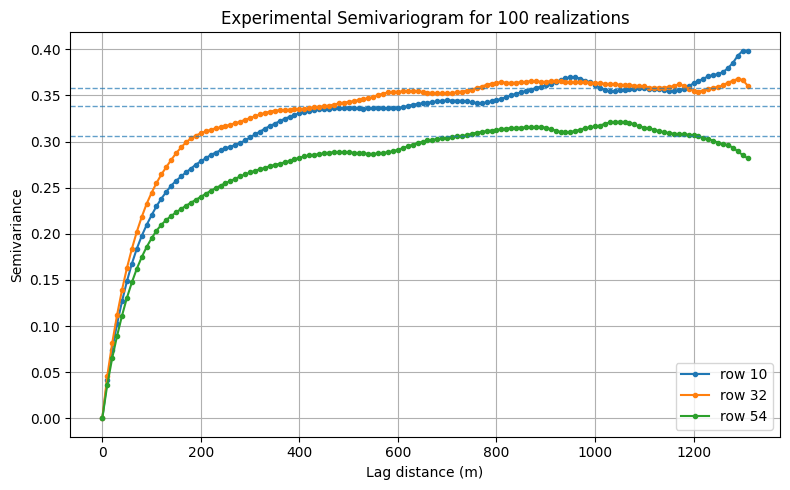

In [33]:
import matplotlib.pyplot as plt
import glob


files = glob.glob("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/trial/100/repaint_sample_*.npy")
samples = np.stack([np.load(f) for f in files], axis=0)
samples = np.squeeze(samples) #remove any extra dimensions if they exist
print(samples.shape)
N, H, W = samples.shape
boundary = 120
points_y = [10, 32, 54]
half_window = 4
pixel_size_m = 10

# only use region to the right of boundary
samples_right = samples[:, :, boundary:]   # shape: (N, H, W_right)

# choose moderate lags
# max_lag = min(60, samples_right.shape[2] - 1)
max_lag = samples_right.shape[2] - 5
lags = np.arange(0, max_lag + 1)

variograms = {}
empirical_vars = {}
pair_counts = {}

# --------------------------------------------------
# Experimental semivariogram:
# gamma(h) = 0.5 * mean[(Z(x+h) - Z(x))^2]
# --------------------------------------------------
for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # shape: (N, n_rows, n_cols)
    window = samples_right[:, y0:y1, :]

    gamma = []
    counts = []

    # empirical variance in this window
    empirical_vars[py] = np.var(window)

    for h in lags:
        if h == 0:
            gamma.append(0.0)
            counts.append(window.size)
            continue

        left = window[:, :, :-h]
        right = window[:, :, h:]

        diffs = right - left
        gamma.append(0.5 * np.mean(diffs ** 2))
        counts.append(diffs.size)

    variograms[py] = np.array(gamma)
    pair_counts[py] = np.array(counts)

# --------------------------------------------------
# Plot semivariogram for each selected row window
# --------------------------------------------------
plt.figure(figsize=(8, 5))
for py, gamma in variograms.items():
    sill_estimate = np.mean(gamma[-5:])
    var = empirical_vars[py]

    print(f"\nRow {py}")
    print(f"Empirical variance: {var:.4f}")
    print(f"Estimated sill: {sill_estimate:.4f}")
    print(f"Ratio: {sill_estimate/var:.3f}")
    plt.plot(
        lags * pixel_size_m,
        gamma,
        marker="o",
        markersize=3,
        label=f"row {py}"
    )
    plt.axhline(
        empirical_vars[py],
        linestyle="--",
        linewidth=1,
        alpha=0.7
    )

plt.xlabel("Lag distance (m)")
plt.ylabel("Semivariance")
plt.title("Experimental Semivariogram for 100 realizations")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("semivarogram_from_diffusion_realizations_100realizations.png", dpi=400, bbox_inches="tight")
plt.show()





## Contour for 100 Realizations

/tmp/ipykernel_1520514/180075683.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


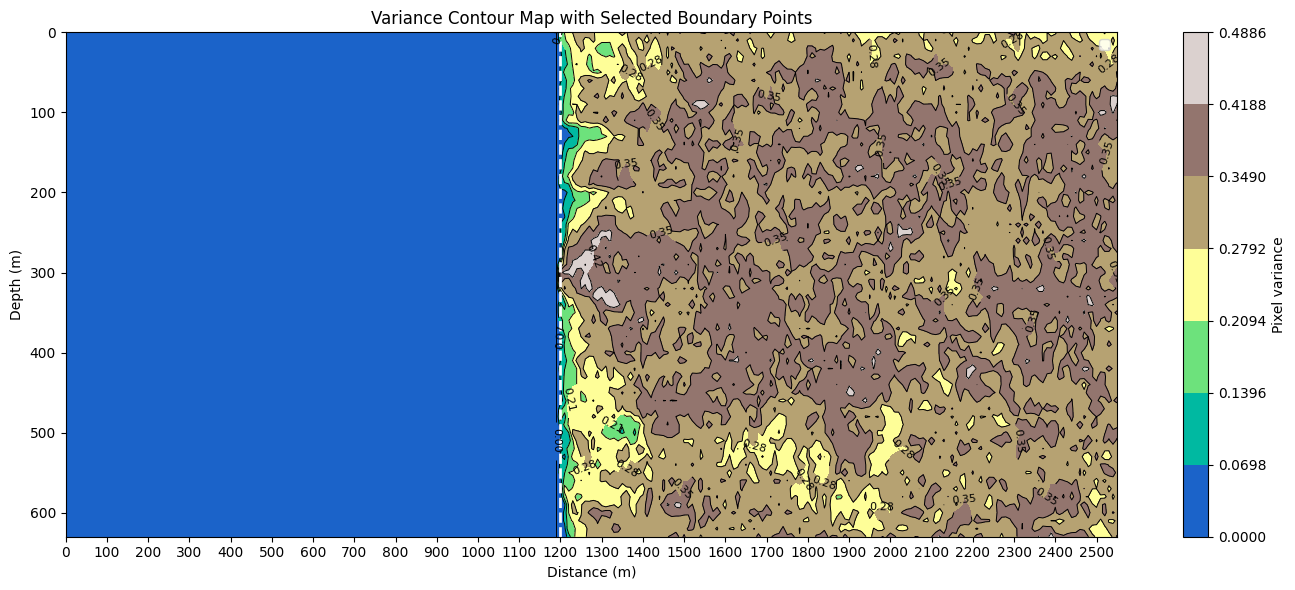

Selected star rows: [10, 32, 54]
Boundary column: 120

STD value at each star:
  row 10: 0.0382
  row 32: 0.2455
  row 54: 0.0914


In [3]:
import numpy as np
import matplotlib.pyplot as plt

pixel_std = np.load(
    "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_std_120_100realizations.npy"
)
pixel_std = np.squeeze(pixel_std)
pixel_std = pixel_std**2 #convertig to variance
pixel_std[pixel_std < 1e-8] = 0 #avoiding numerical issues
#variance is zero but before the contour was showing line for tiny floating-point differences

H, W = pixel_std.shape



x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

boundary = 120   #150 or 180

#coundaries
points_y = [10, H // 2, H - 10]
points_x = [boundary] * len(points_y)

levels = np.linspace(pixel_std.min(), pixel_std.max(), 8)

fig, ax = plt.subplots(figsize=(14, 6))
cf = ax.contourf(X, Y, pixel_std, levels=levels, cmap="terrain")
cs = ax.contour(X, Y, pixel_std, levels=levels, colors="black", linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.axvline(boundary, color="white", linestyle="--", linewidth=2)

# ax.plot(points_x, points_y, "*", color="red", markersize=14)
xticks = np.arange(0, W, 10)
yticks = np.arange(0, H, 10)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels(xticks * 10)
ax.set_yticklabels(yticks * 10)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

ax.invert_yaxis()
ax.set_title("Variance Contour Map with Selected Boundary Points")
ax.legend()

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel variance")

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/contour_map/100_variance_contour_with_stars_meters.png", dpi=300, bbox_inches="tight")
plt.show()


#variogram for each star
max_lag = W - boundary - 5  
lags = np.arange(1, max_lag)
half_window = 4  # to average over a small window around the star
data = pixel_std[:, boundary:]
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # window of rows around the selected point
    window = data[y0:y1, :]   # shape: (n_rows, n_cols)

    gamma = []

    for h in lags:
        if h == 0:
            continue
        diffs = []

        for r in range(window.shape[0]):
            row = window[r, :]

            # all pairs separated by lag h
            d = row[h:] - row[:-h]
            diffs.extend(d ** 2)

        # semivariance = 0.5 * mean squared difference
        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)


print("Selected star rows:", points_y)
print("Boundary column:", boundary)
print("\nSTD value at each star:")
for py in points_y:
    print(f"  row {py}: {pixel_std[py, boundary]:.4f}")

# print("\nMean semivariance at final lag:", mean_gamma[-1])


## 1. Test data

##### test data: /Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/slice_XZ_numpy_patches

Total patch files found: 2200
Test data shape: (100, 64, 256)
Shape after squeeze: (100, 64, 256)


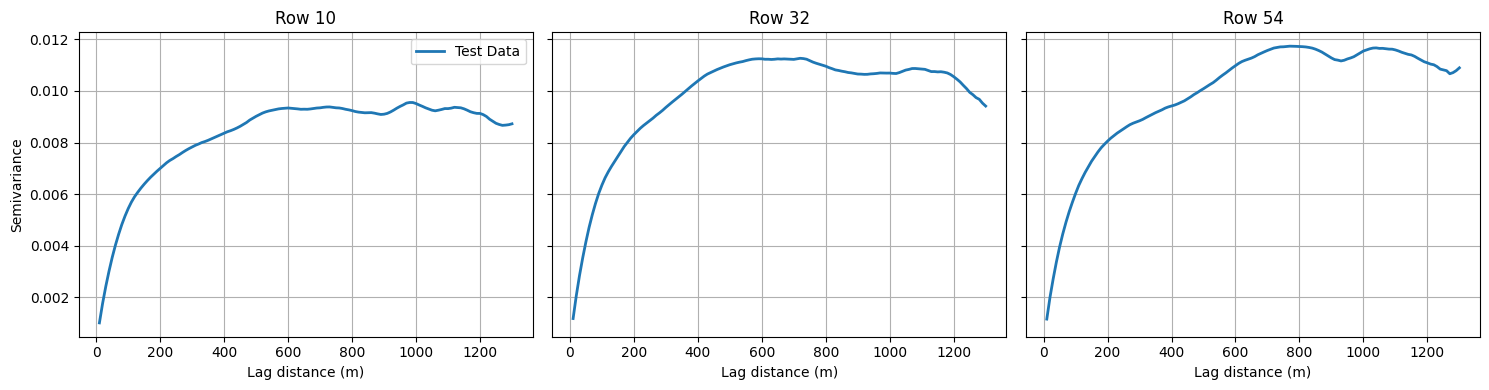

Used 100 test patches
Selected rows: [10, 32, 54]
Boundary: 120


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# PATH TO TEST DATA PATCHES
# -----------------------------------
patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/slice_XZ_numpy_patches"

# get all .npy files
patch_files = sorted(glob.glob(os.path.join(patch_folder, "*.npy")))

print(f"Total patch files found: {len(patch_files)}")

# -----------------------------------
# SELECT 100 RANDOM PATCHES
# -----------------------------------
np.random.seed(0)
selected_files = np.random.choice(patch_files, 100, replace=False)

# load selected patches
test_data = np.stack([np.load(f) for f in selected_files])

print("Test data shape:", test_data.shape)   # should be (100, H, W)

# if patches have extra singleton dimension, remove it
test_data = np.squeeze(test_data)
print("Shape after squeeze:", test_data.shape)

N, H, W = test_data.shape

# -----------------------------------
# PARAMETERS
# -----------------------------------
boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

# -----------------------------------
# COMPUTE VARIOGRAMS
# -----------------------------------
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    gamma = []

    for h in lags:
        diffs = []

        for n in range(N):
            window = test_data[n, y0:y1, boundary:]   # rows around selected point

            for r in range(window.shape[0]):
                row = window[r, :]
                d = row[h:] - row[:-h]
                diffs.extend(d**2)

        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)

# -----------------------------------
# PLOT
# -----------------------------------
lags_m = lags * 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags_m, variograms[py], label="Test Data", linewidth=2)
    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag distance (m)")
    axes[i].grid(True)

axes[0].set_ylabel("Semivariance")
axes[0].legend()

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/100_variogram_test_vs_unconditional_meters.png", dpi=300)
plt.show()

# -----------------------------------
# INFO
# -----------------------------------
print("Used 100 test patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

In [10]:
sample = np.load(patch_files[0])
print(sample.shape)

(64, 256)


## Unconditional

unconditional samples: /Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/train_generated_patches/patch_epoch_{epoch}.npy

In [26]:
import numpy as np

epoch = 120  # or whichever epoch you want
file_path = f"/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/train_generated_patches/patch_epoch_100.npy"

samples = np.load(file_path)
print(samples.shape)

(1, 1, 64, 256)


In [27]:
uncond_data = np.squeeze(samples)[:100]
print(uncond_data.shape)

(64, 256)


Total patch files found: 100
Unconditional variograms shape: (100, 1, 1, 64, 256)
Shape after squeeze: (100, 64, 256)


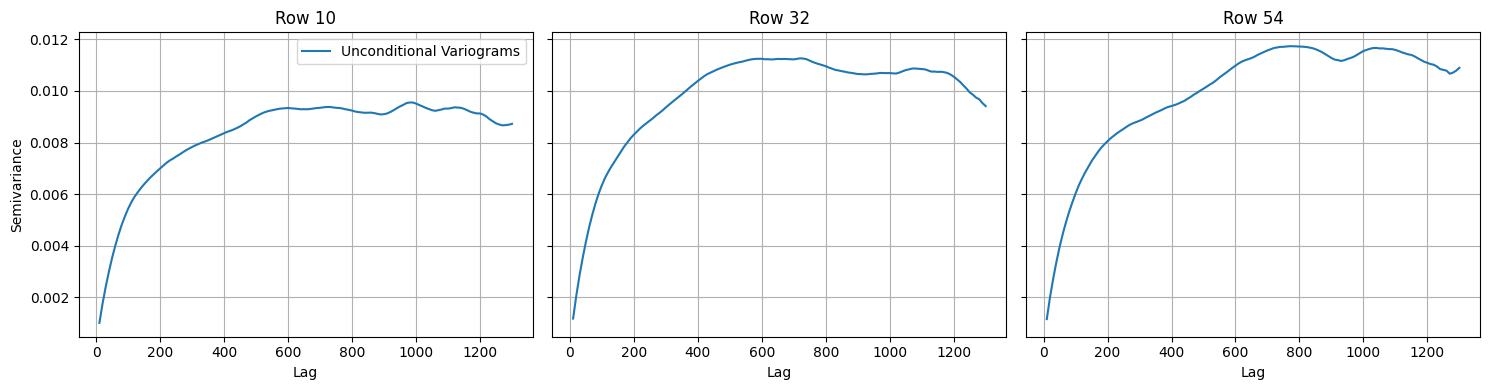

Used 100 Unconditional patches
Selected rows: [10, 32, 54]
Boundary: 120


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# PATH TO TEST DATA PATCHES
# -----------------------------------
patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/train_generated_patches"

# get all .npy files
patch_files = sorted(glob.glob(os.path.join(patch_folder, "*.npy")))

print(f"Total patch files found: {len(patch_files)}")

# -----------------------------------
# SELECT 100 RANDOM PATCHES
# -----------------------------------
np.random.seed(0)
selected_files = np.random.choice(patch_files, 100, replace=False)

# load selected patches
variograms_uncond = np.stack([np.load(f) for f in selected_files])

print("Unconditional variograms shape:", variograms_uncond.shape)

# if patches have extra singleton dimension, remove it
variograms_uncond = np.squeeze(variograms_uncond)
print("Shape after squeeze:", variograms_uncond.shape)

N, H, W = variograms_uncond.shape

# -----------------------------------
# PARAMETERS
# -----------------------------------
boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

# -----------------------------------
# COMPUTE VARIOGRAMS
# -----------------------------------
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    gamma = []

    for h in lags:
        diffs = []

        for n in range(N):
            window = test_data[n, y0:y1, boundary:]   # rows around selected point

            for r in range(window.shape[0]):
                row = window[r, :]
                d = row[h:] - row[:-h]
                diffs.extend(d**2)

        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)


lags = lags * 10  # convert to meters
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags, variograms[py], label="Unconditional Variograms")
    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag")
    axes[i].grid(True)

axes[0].set_ylabel("Semivariance")
axes[0].legend()

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/100_variogram_uncond.png", dpi=300)
plt.show()


print("Used 100 Unconditional patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

conditioning does change the spatial structure but higher variance compare to test data. 

unconditional model partially captures spatial variability but fails to accurately reproduce the true spatial correlation structure observed in the test data.

### Conditional 50 samples

Total patch files found: 50
Test data shape: (50, 1, 1, 64, 256)
Shape after squeeze: (50, 64, 256)


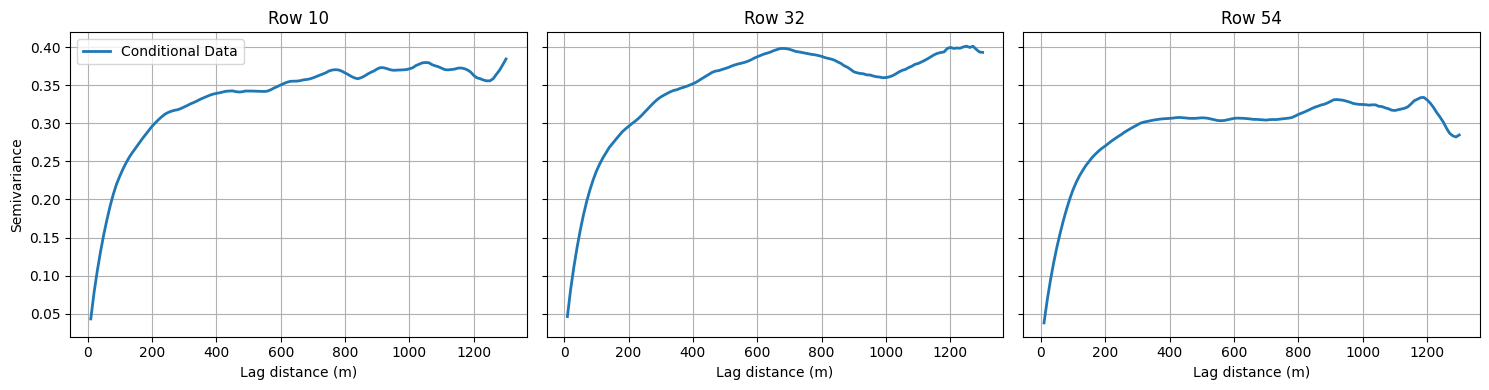

Used 50 test patches
Selected rows: [10, 32, 54]
Boundary: 120


In [11]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# PATH TO TEST DATA PATCHES
# -----------------------------------
patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/trial/50"

# get all .npy files
patch_files = sorted(glob.glob(os.path.join(patch_folder, "*.npy")))

print(f"Total patch files found: {len(patch_files)}")

# -----------------------------------
# SELECT 100 RANDOM PATCHES
# -----------------------------------
np.random.seed(0)
selected_files = np.random.choice(patch_files, 50, replace=False)

# load selected patches
test_data = np.stack([np.load(f) for f in selected_files])

print("Test data shape:", test_data.shape)   # should be (100, H, W)

# if patches have extra singleton dimension, remove it
test_data = np.squeeze(test_data)
print("Shape after squeeze:", test_data.shape)

N, H, W = test_data.shape

# -----------------------------------
# PARAMETERS
# -----------------------------------
boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

# -----------------------------------
# COMPUTE VARIOGRAMS
# -----------------------------------
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    gamma = []

    for h in lags:
        diffs = []

        for n in range(N):
            window = test_data[n, y0:y1, boundary:]   # rows around selected point

            for r in range(window.shape[0]):
                row = window[r, :]
                d = row[h:] - row[:-h]
                diffs.extend(d**2)

        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)

# -----------------------------------
# PLOT
# -----------------------------------
lags_m = lags * 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags_m, variograms[py], label="Conditional Data", linewidth=2)
    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag distance (m)")
    axes[i].grid(True)

axes[0].set_ylabel("Semivariance")
axes[0].legend()

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/50_variogram_cond.png", dpi=300)
plt.show()

# -----------------------------------
# INFO
# -----------------------------------
print("Used 50 test patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

### Conditional 100 samples

Total patch files found: 100
Test data shape: (100, 1, 1, 64, 256)
Shape after squeeze: (100, 64, 256)


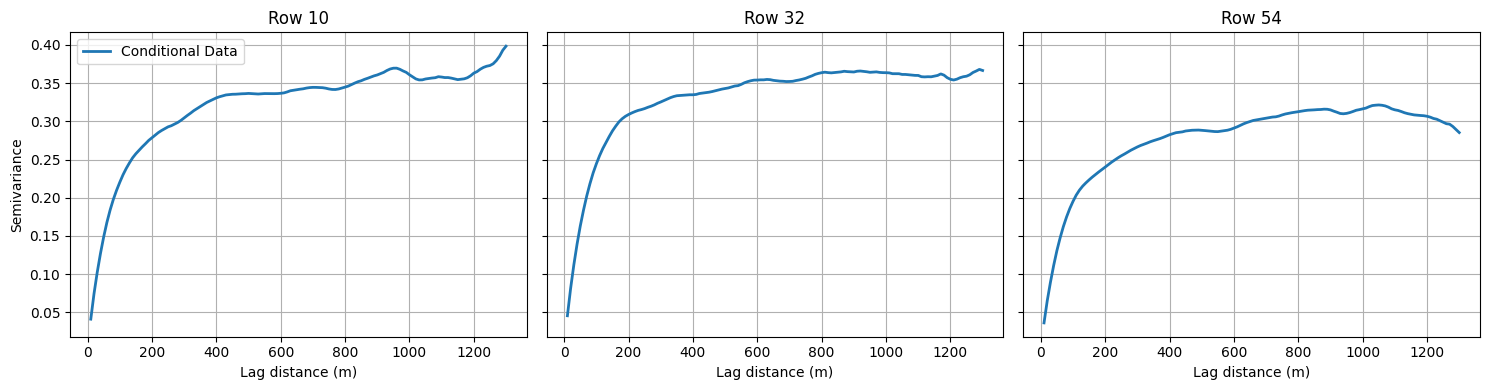

Used 50 test patches
Selected rows: [10, 32, 54]
Boundary: 120


In [9]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# PATH TO TEST DATA PATCHES
# -----------------------------------
patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/trial/100"

# get all .npy files
patch_files = sorted(glob.glob(os.path.join(patch_folder, "*.npy")))

print(f"Total patch files found: {len(patch_files)}")

# -----------------------------------
# SELECT 100 RANDOM PATCHES
# -----------------------------------
np.random.seed(0)
selected_files = np.random.choice(patch_files, 100, replace=False)

# load selected patches
test_data = np.stack([np.load(f) for f in selected_files])

print("Test data shape:", test_data.shape)   # should be (100, H, W)

# if patches have extra singleton dimension, remove it
test_data = np.squeeze(test_data)
print("Shape after squeeze:", test_data.shape)

N, H, W = test_data.shape

# -----------------------------------
# PARAMETERS
# -----------------------------------
boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

# -----------------------------------
# COMPUTE VARIOGRAMS
# -----------------------------------
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    gamma = []

    for h in lags:
        diffs = []

        for n in range(N):
            window = test_data[n, y0:y1, boundary:]   # rows around selected point

            for r in range(window.shape[0]):
                row = window[r, :]
                d = row[h:] - row[:-h]
                diffs.extend(d**2)

        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)

# -----------------------------------
# PLOT
# -----------------------------------
lags_m = lags * 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags_m, variograms[py], label="Conditional Data", linewidth=2)
    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag distance (m)")
    axes[i].grid(True)

axes[0].set_ylabel("Semivariance")
axes[0].legend()

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/100_variogram_cond.png", dpi=300)
plt.show()

# -----------------------------------
# INFO
# -----------------------------------
print("Used 50 test patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

### 50 Normalized Samples
#### 1. Variogram

Total patch files found: 50
Test data shape: (50, 1, 1, 64, 256)
Shape after squeeze: (50, 64, 256)


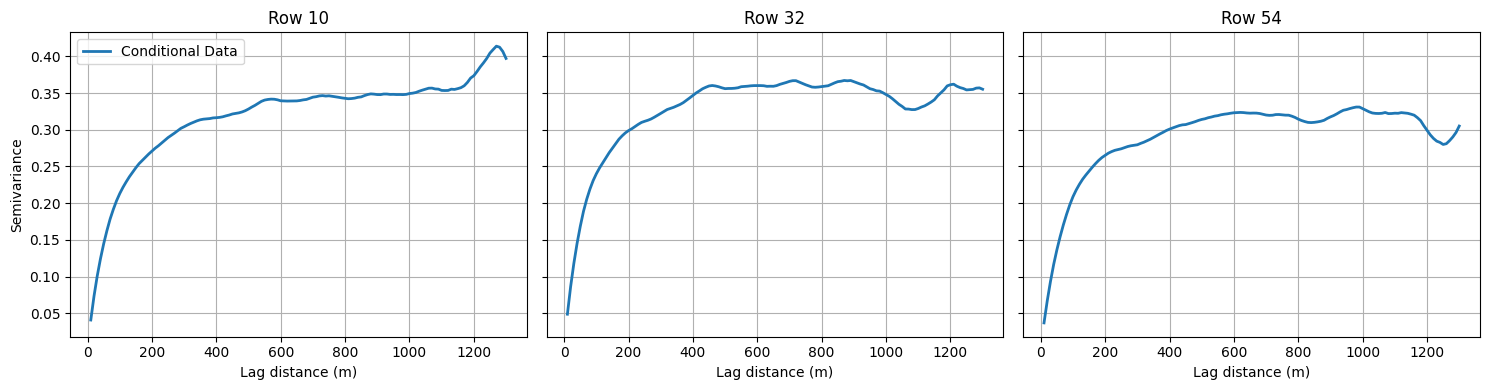

Used 50 test patches
Selected rows: [10, 32, 54]
Boundary: 120


In [14]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# PATH TO TEST DATA PATCHES
# -----------------------------------
patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/final"

# get all .npy files
patch_files = sorted(glob.glob(os.path.join(patch_folder, "*.npy")))

print(f"Total patch files found: {len(patch_files)}")

# -----------------------------------
# SELECT 100 RANDOM PATCHES
# -----------------------------------
np.random.seed(0)
selected_files = np.random.choice(patch_files, 50, replace=False)

# load selected patches
test_data = np.stack([np.load(f) for f in selected_files])

print("Test data shape:", test_data.shape)   # should be (100, H, W)

# if patches have extra singleton dimension, remove it
test_data = np.squeeze(test_data)
print("Shape after squeeze:", test_data.shape)

N, H, W = test_data.shape

# -----------------------------------
# PARAMETERS
# -----------------------------------
boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

# -----------------------------------
# COMPUTE VARIOGRAMS
# -----------------------------------
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    gamma = []

    for h in lags:
        diffs = []

        for n in range(N):
            window = test_data[n, y0:y1, boundary:]   # rows around selected point

            for r in range(window.shape[0]):
                row = window[r, :]
                d = row[h:] - row[:-h]
                diffs.extend(d**2)

        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)

# -----------------------------------
# PLOT
# -----------------------------------
lags_m = lags * 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags_m, variograms[py], label="Conditional Data", linewidth=2)
    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag distance (m)")
    axes[i].grid(True)

axes[0].set_ylabel("Semivariance")
axes[0].legend()

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/50_Normalized_variogram_cond.png", dpi=300)
plt.show()

# -----------------------------------
# INFO
# -----------------------------------
print("Used 50 test patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

### 2. Contour

# 1000 Samples
## 1. Conditional
#### Variogram

Total patch files found: 1000
Test data shape: (1000, 1, 1, 64, 256)
Shape after squeeze: (1000, 64, 256)


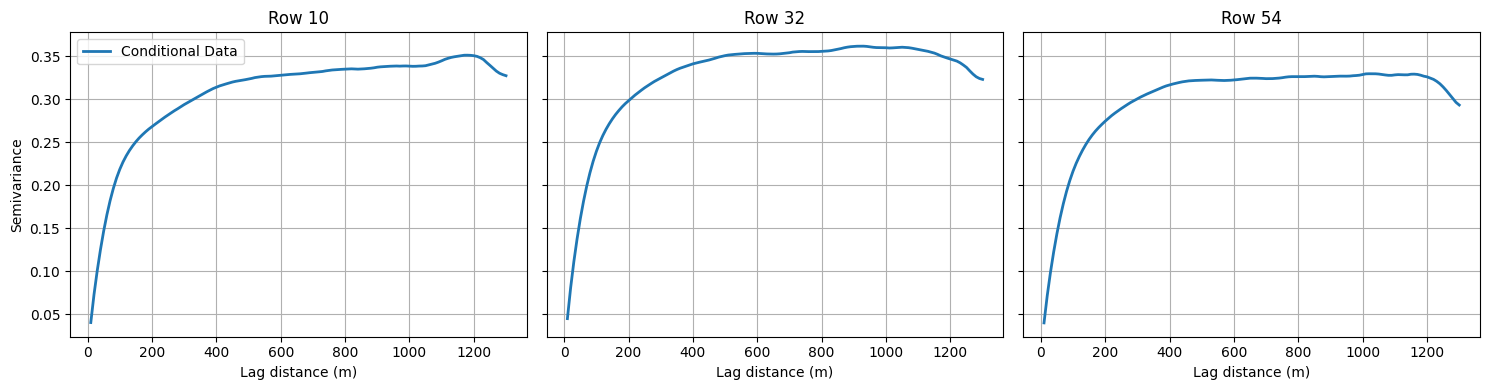

Used 1000 test patches
Selected rows: [10, 32, 54]
Boundary: 120


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# PATH TO TEST DATA PATCHES
# -----------------------------------
patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/final"

# get all .npy files
patch_files = sorted(glob.glob(os.path.join(patch_folder, "*.npy")))

print(f"Total patch files found: {len(patch_files)}")

# -----------------------------------
# SELECT 100 RANDOM PATCHES
# -----------------------------------
np.random.seed(0)
selected_files = np.random.choice(patch_files, 1000, replace=False)

# load selected patches
test_data = np.stack([np.load(f) for f in selected_files])

print("Conditional data shape:", test_data.shape)   # should be (100, H, W)

# if patches have extra singleton dimension, remove it
test_data = np.squeeze(test_data)
print("Shape after squeeze:", test_data.shape)

N, H, W = test_data.shape

# -----------------------------------
# PARAMETERS
# -----------------------------------
boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

# -----------------------------------
# COMPUTE VARIOGRAMS
# -----------------------------------
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    gamma = []

    for h in lags:
        diffs = []

        for n in range(N):
            window = test_data[n, y0:y1, boundary:]   # rows around selected point

            for r in range(window.shape[0]):
                row = window[r, :]
                d = row[h:] - row[:-h]
                diffs.extend(d**2)

        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)

# -----------------------------------
# PLOT
# -----------------------------------
lags_m = lags * 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags_m, variograms[py], label="Conditional Data", linewidth=2)
    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag distance (m)")
    axes[i].grid(True)

axes[0].set_ylabel("Semivariance")
axes[0].legend()

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/1000_Normalized_variogram_cond.png", dpi=300)
plt.show()

# -----------------------------------
# INFO
# -----------------------------------
print("Used 1000 conditional  patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

Total sample files found: 1000
Conditional data shape: (1000, 1, 1, 64, 256)
Shape after squeeze: (1000, 64, 256)


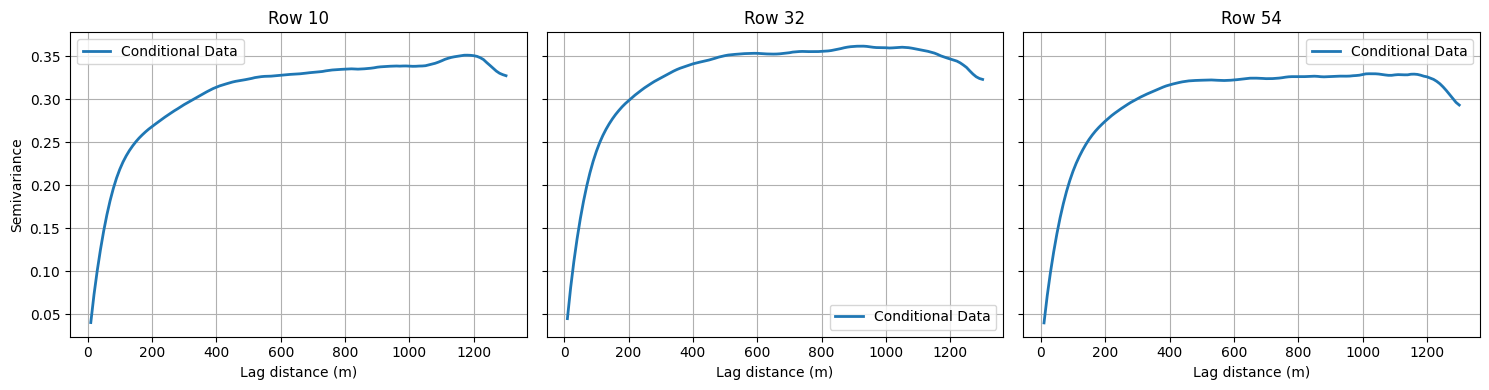


===== SILL CHECK =====

Row 10
Empirical variance: 0.3373
Estimated sill:     0.3369
Ratio sill/var:     0.999

Row 32
Empirical variance: 0.3548
Estimated sill:     0.3585
Ratio sill/var:     1.010

Row 54
Empirical variance: 0.3299
Estimated sill:     0.3269
Ratio sill/var:     0.991

Used 1000 conditional patches
Selected rows: [10, 32, 54]
Boundary: 120


In [6]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/repaint_ensemble/final"

# Only individual samples, not ensemble.npy
patch_files = sorted(glob.glob(os.path.join(patch_folder, "sample_*.npy")))

print(f"Total sample files found: {len(patch_files)}")

np.random.seed(0)
selected_files = np.random.choice(patch_files, 1000, replace=False)

test_data = np.stack([np.load(f) for f in selected_files])
print("Conditional data shape:", test_data.shape)

test_data = np.squeeze(test_data)
print("Shape after squeeze:", test_data.shape)

N, H, W = test_data.shape

boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4
pixel_size_m = 10

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

variograms = {}
empirical_vars = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # Same spatial window used for variogram
    window_all = test_data[:, y0:y1, boundary:]

    # Empirical variance of that window
    empirical_vars[py] = np.var(window_all)

    gamma = []

    for h in lags:
        left = window_all[:, :, :-h]
        right = window_all[:, :, h:]

        diffs = right - left
        gamma.append(0.5 * np.mean(diffs ** 2))

    variograms[py] = np.array(gamma)

# -----------------------------------
# PLOT
# -----------------------------------
lags_m = lags * pixel_size_m

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags_m, variograms[py], label="Conditional Data", linewidth=2)

    # # empirical variance = expected sill
    # axes[i].axhline(
    #     empirical_vars[py],
    #     linestyle="--",
    #     linewidth=1.5,
    #     label=f"Empirical variance = {empirical_vars[py]:.3f}"
    # )

    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag distance (m)")
    axes[i].grid(True)
    axes[i].legend()

axes[0].set_ylabel("Semivariance")

plt.tight_layout()
plt.savefig(
    "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/1000_Normalized_variogram_cond.png",
    dpi=300
)
plt.show()

# -----------------------------------
# SILL CHECK
# -----------------------------------
print("\n===== SILL CHECK =====")

# Use stable plateau region, avoid final edge-effect tail
plateau_mask = (lags_m >= 700) & (lags_m <= 1100)

for py in points_y:
    sill_estimate = np.mean(variograms[py][plateau_mask])
    var = empirical_vars[py]

    print(f"\nRow {py}")
    print(f"Empirical variance: {var:.4f}")
    print(f"Estimated sill:     {sill_estimate:.4f}")
    print(f"Ratio sill/var:     {sill_estimate / var:.3f}")

print("\nUsed 1000 conditional patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

#### Contour Map

/tmp/ipykernel_3274872/3635284479.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


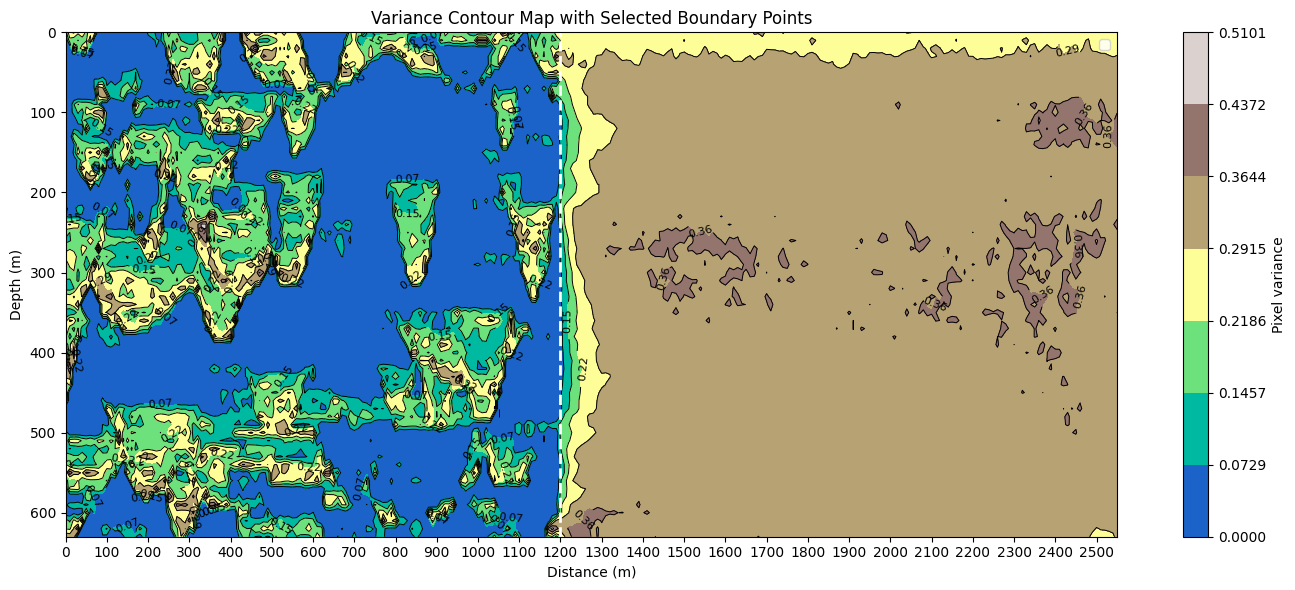

Selected star rows: [10, 32, 54]
Boundary column: 120

STD value at each star:
  row 10: 0.0644
  row 32: 0.0546
  row 54: 0.0843


In [14]:
import numpy as np
import matplotlib.pyplot as plt

pixel_std = np.load(
    "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/unpixel_std_120_1000.npy"
)
pixel_std = np.squeeze(pixel_std)
pixel_std = pixel_std**2 #convertig to variance
pixel_std[pixel_std < 1e-8] = 0 #avoiding numerical issues
#variance is zero but before the contour was showing line for tiny floating-point differences

H, W = pixel_std.shape



x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

boundary = 120   #150 or 180

#coundaries
points_y = [10, H // 2, H - 10]
points_x = [boundary] * len(points_y)

levels = np.linspace(pixel_std.min(), pixel_std.max(), 8)

fig, ax = plt.subplots(figsize=(14, 6))
cf = ax.contourf(X, Y, pixel_std, levels=levels, cmap="terrain")
cs = ax.contour(X, Y, pixel_std, levels=levels, colors="black", linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.axvline(boundary, color="white", linestyle="--", linewidth=2)

# ax.plot(points_x, points_y, "*", color="red", markersize=14)
xticks = np.arange(0, W, 10)
yticks = np.arange(0, H, 10)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels(xticks * 10)
ax.set_yticklabels(yticks * 10)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

ax.invert_yaxis()
ax.set_title("Variance Contour Map with Selected Boundary Points")
ax.legend()

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel variance")

plt.tight_layout()
# plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/contour_map/1000_variance_contour_with_stars_meters.png", dpi=300, bbox_inches="tight")
plt.show()


#variogram for each star
max_lag = W - boundary - 5  
lags = np.arange(1, max_lag)
half_window = 4  # to average over a small window around the star
data = pixel_std[:, boundary:]
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # window of rows around the selected point
    window = data[y0:y1, :]   # shape: (n_rows, n_cols)

    gamma = []

    for h in lags:
        if h == 0:
            continue
        diffs = []

        for r in range(window.shape[0]):
            row = window[r, :]

            # all pairs separated by lag h
            d = row[h:] - row[:-h]
            diffs.extend(d ** 2)

        # semivariance = 0.5 * mean squared difference
        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)


print("Selected star rows:", points_y)
print("Boundary column:", boundary)
print("\nSTD value at each star:")
for py in points_y:
    print(f"  row {py}: {pixel_std[py, boundary]:.4f}")

# print("\nMean semivariance at final lag:", mean_gamma[-1])


## 2. Test Data
### Variogram

Total patch files found: 2200
Test data shape: (1000, 64, 256)
Shape after squeeze: (1000, 64, 256)


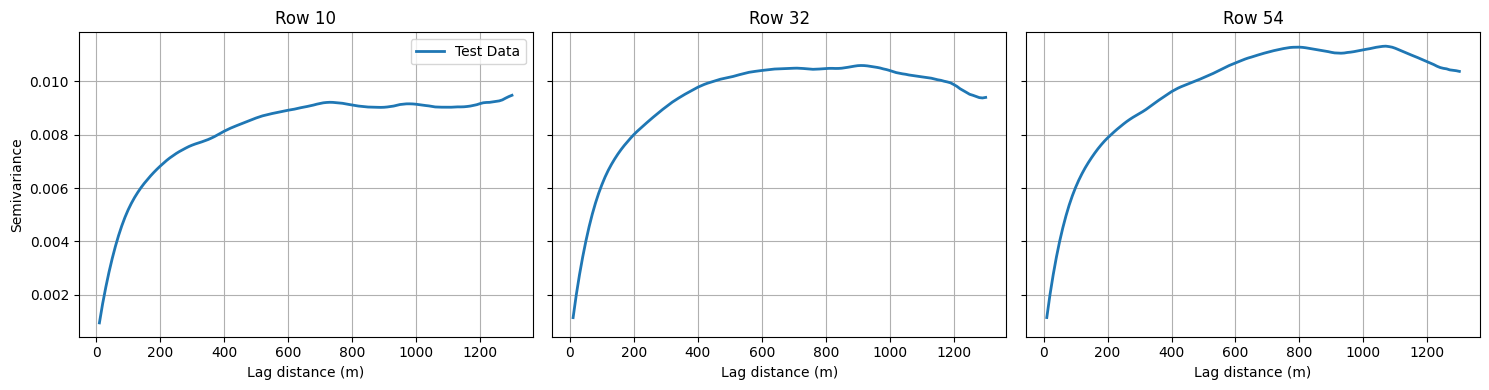

Used 1000 test patches
Selected rows: [10, 32, 54]
Boundary: 120


In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# PATH TO TEST DATA PATCHES
# -----------------------------------
patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/slice_XZ_numpy_patches"

# get all .npy files
patch_files = sorted(glob.glob(os.path.join(patch_folder, "*.npy")))

print(f"Total patch files found: {len(patch_files)}")

# -----------------------------------
# SELECT 100 RANDOM PATCHES
# -----------------------------------
np.random.seed(0)
selected_files = np.random.choice(patch_files, 1000, replace=False)

# load selected patches
test_data = np.stack([np.load(f) for f in selected_files])

print("Test data shape:", test_data.shape)   # should be (1000, H, W)

# if patches have extra singleton dimension, remove it
test_data = np.squeeze(test_data)
print("Shape after squeeze:", test_data.shape)

N, H, W = test_data.shape

# -----------------------------------
# PARAMETERS
# -----------------------------------
boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

# -----------------------------------
# COMPUTE VARIOGRAMS
# -----------------------------------
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    gamma = []

    for h in lags:
        diffs = []

        for n in range(N):
            window = test_data[n, y0:y1, boundary:]   # rows around selected point

            for r in range(window.shape[0]):
                row = window[r, :]
                d = row[h:] - row[:-h]
                diffs.extend(d**2)

        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)

# -----------------------------------
# PLOT
# -----------------------------------
lags_m = lags * 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags_m, variograms[py], label="Test Data", linewidth=2)
    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag distance (m)")
    axes[i].grid(True)

axes[0].set_ylabel("Semivariance")
axes[0].legend()

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/1000_variogram_test_vs_unconditional_meters.png", dpi=300)
plt.show()

# -----------------------------------
# INFO
# -----------------------------------
print("Used 1000 test patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

### Contour Map

/tmp/ipykernel_3274872/241366376.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


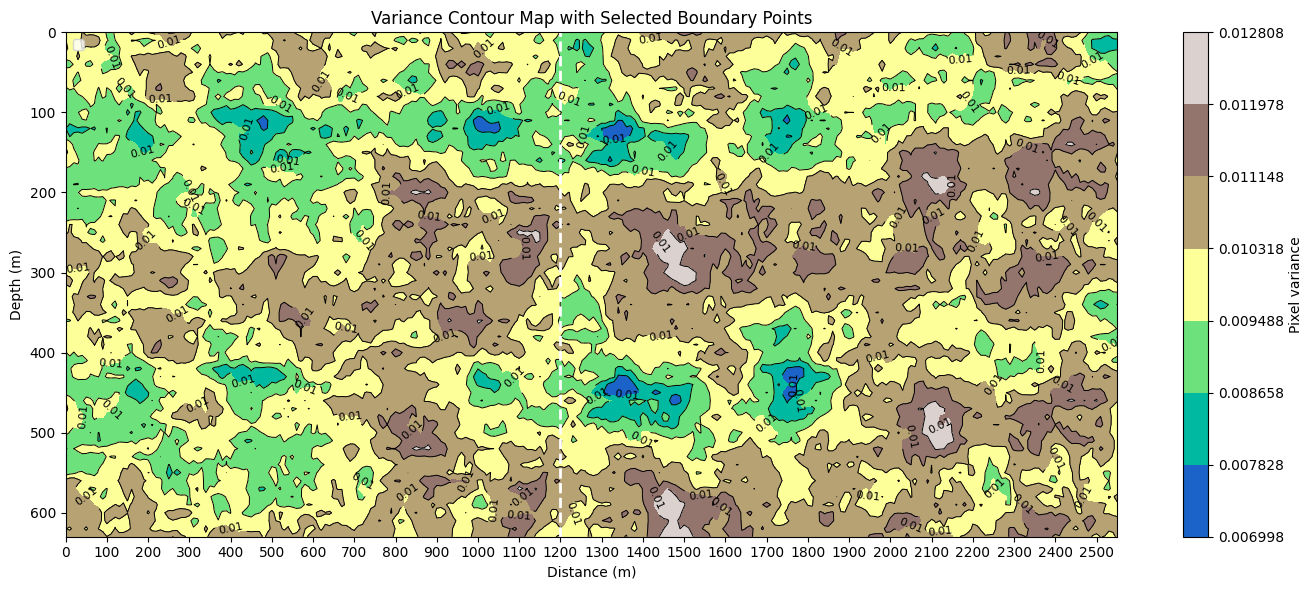

Selected star rows: [10, 32, 54]
Boundary column: 120

STD value at each star:
  row 10: 0.0095
  row 32: 0.0100
  row 54: 0.0102


In [8]:
import numpy as np
import matplotlib.pyplot as plt

pixel_std = np.load(
    "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/test_pixel_std_120_1000.npy"
)
pixel_std = np.squeeze(pixel_std)
pixel_std = pixel_std**2 #convertig to variance
pixel_std[pixel_std < 1e-8] = 0 #avoiding numerical issues
#variance is zero but before the contour was showing line for tiny floating-point differences

H, W = pixel_std.shape



x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

boundary = 120   #150 or 180

#coundaries
points_y = [10, H // 2, H - 10]
points_x = [boundary] * len(points_y)

levels = np.linspace(pixel_std.min(), pixel_std.max(), 8)

fig, ax = plt.subplots(figsize=(14, 6))
cf = ax.contourf(X, Y, pixel_std, levels=levels, cmap="terrain")
cs = ax.contour(X, Y, pixel_std, levels=levels, colors="black", linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.axvline(boundary, color="white", linestyle="--", linewidth=2)

# ax.plot(points_x, points_y, "*", color="red", markersize=14)
xticks = np.arange(0, W, 10)
yticks = np.arange(0, H, 10)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels(xticks * 10)
ax.set_yticklabels(yticks * 10)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

ax.invert_yaxis()
ax.set_title("Variance Contour Map with Selected Boundary Points")
ax.legend()

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel variance")

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/contour_map/test_1000_variance_contour_with_stars_meters.png", dpi=300, bbox_inches="tight")
plt.show()


#variogram for each star
max_lag = W - boundary - 5  
lags = np.arange(1, max_lag)
half_window = 4  # to average over a small window around the star
data = pixel_std[:, boundary:]
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # window of rows around the selected point
    window = data[y0:y1, :]   # shape: (n_rows, n_cols)

    gamma = []

    for h in lags:
        if h == 0:
            continue
        diffs = []

        for r in range(window.shape[0]):
            row = window[r, :]

            # all pairs separated by lag h
            d = row[h:] - row[:-h]
            diffs.extend(d ** 2)

        # semivariance = 0.5 * mean squared difference
        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)


print("Selected star rows:", points_y)
print("Boundary column:", boundary)
print("\nSTD value at each star:")
for py in points_y:
    print(f"  row {py}: {pixel_std[py, boundary]:.4f}")

# print("\nMean semivariance at final lag:", mean_gamma[-1])


## 3. Unconditional
### Variogram

Total patch files found: 100
Unconditional variograms shape: (100, 1, 1, 64, 256)
Shape after squeeze: (100, 64, 256)


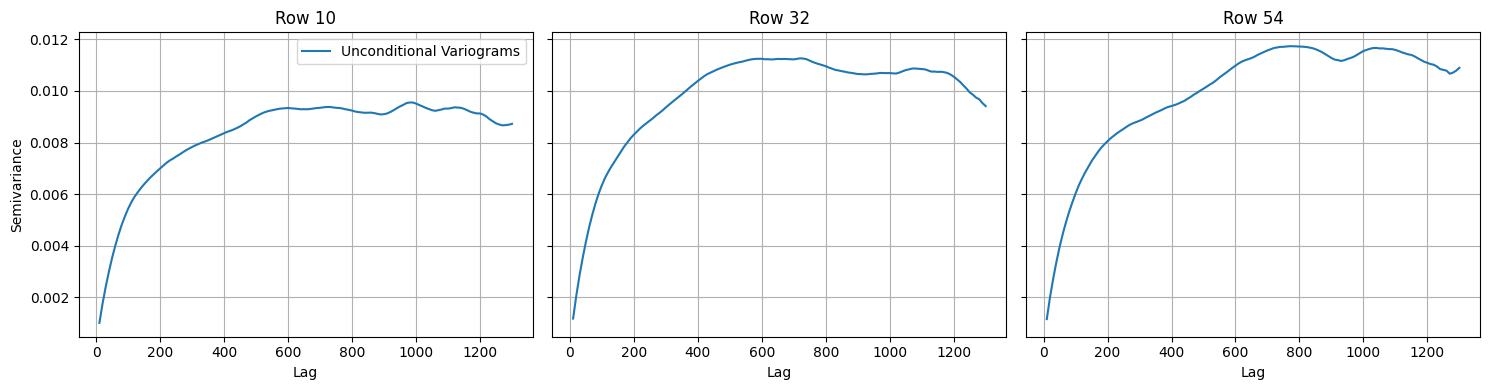

Used 1000 Unconditional patches
Selected rows: [10, 32, 54]
Boundary: 120


In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# PATH TO TEST DATA PATCHES
# -----------------------------------
patch_folder = "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/train_generated_patches"

# get all .npy files
patch_files = sorted(glob.glob(os.path.join(patch_folder, "*.npy")))

print(f"Total patch files found: {len(patch_files)}")

# -----------------------------------
# SELECT 100 RANDOM PATCHES
# -----------------------------------
np.random.seed(0)
selected_files = np.random.choice(patch_files, 100, replace=False)

# load selected patches
variograms_uncond = np.stack([np.load(f) for f in selected_files])

print("Unconditional variograms shape:", variograms_uncond.shape)

# if patches have extra singleton dimension, remove it
variograms_uncond = np.squeeze(variograms_uncond)
print("Shape after squeeze:", variograms_uncond.shape)

N, H, W = variograms_uncond.shape

# -----------------------------------
# PARAMETERS
# -----------------------------------
boundary = 120
points_y = [10, H // 2, H - 10]
half_window = 4

max_lag = W - boundary - 5
lags = np.arange(1, max_lag)

# -----------------------------------
# COMPUTE VARIOGRAMS
# -----------------------------------
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    gamma = []

    for h in lags:
        diffs = []

        for n in range(N):
            window = test_data[n, y0:y1, boundary:]   # rows around selected point

            for r in range(window.shape[0]):
                row = window[r, :]
                d = row[h:] - row[:-h]
                diffs.extend(d**2)

        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)


lags = lags * 10  # convert to meters
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, py in enumerate(points_y):
    axes[i].plot(lags, variograms[py], label="Unconditional Variograms")
    axes[i].set_title(f"Row {py}")
    axes[i].set_xlabel("Lag")
    axes[i].grid(True)

axes[0].set_ylabel("Semivariance")
axes[0].legend()

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/variograms/1000_variogram_uncond.png", dpi=300)
plt.show()


print("Used 1000 Unconditional patches")
print("Selected rows:", points_y)
print("Boundary:", boundary)

### Contour Map

In [3]:
import numpy as np
import matplotlib.pyplot as plt

pixel_std = np.load(
    "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/train_geology_output/model100.pth"
)
pixel_std = np.squeeze(pixel_std)
pixel_std = pixel_std**2 #convertig to variance
pixel_std[pixel_std < 1e-8] = 0 #avoiding numerical issues
#variance is zero but before the contour was showing line for tiny floating-point differences

H, W = pixel_std.shape



x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

boundary = 120   #150 or 180

#coundaries
points_y = [10, H // 2, H - 10]
points_x = [boundary] * len(points_y)

levels = np.linspace(pixel_std.min(), pixel_std.max(), 8)

fig, ax = plt.subplots(figsize=(14, 6))
cf = ax.contourf(X, Y, pixel_std, levels=levels, cmap="terrain")
cs = ax.contour(X, Y, pixel_std, levels=levels, colors="black", linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.axvline(boundary, color="white", linestyle="--", linewidth=2)

# ax.plot(points_x, points_y, "*", color="red", markersize=14)
xticks = np.arange(0, W, 10)
yticks = np.arange(0, H, 10)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels(xticks * 10)
ax.set_yticklabels(yticks * 10)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

ax.invert_yaxis()
ax.set_title("Variance Contour Map with Selected Boundary Points")
ax.legend()

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel variance")

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/contour_map/uncond_1000_variance_contour_with_stars_meters.png", dpi=300, bbox_inches="tight")
plt.show()


#variogram for each star
max_lag = W - boundary - 5  
lags = np.arange(1, max_lag)
half_window = 4  # to average over a small window around the star
data = pixel_std[:, boundary:]
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # window of rows around the selected point
    window = data[y0:y1, :]   # shape: (n_rows, n_cols)

    gamma = []

    for h in lags:
        if h == 0:
            continue
        diffs = []

        for r in range(window.shape[0]):
            row = window[r, :]

            # all pairs separated by lag h
            d = row[h:] - row[:-h]
            diffs.extend(d ** 2)

        # semivariance = 0.5 * mean squared difference
        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)


print("Selected star rows:", points_y)
print("Boundary column:", boundary)
print("\nSTD value at each star:")
for py in points_y:
    print(f"  row {py}: {pixel_std[py, boundary]:.4f}")

# print("\nMean semivariance at final lag:", mean_gamma[-1])


TypeError: ufunc 'square' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pixel_std = np.load(
    "/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/pixel_std_120_1000.npy"
)
pixel_std = np.squeeze(pixel_std)
pixel_std = pixel_std**2 #convertig to variance
pixel_std[pixel_std < 1e-8] = 0 #avoiding numerical issues
#variance is zero but before the contour was showing line for tiny floating-point differences

H, W = pixel_std.shape



x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)

boundary = 120   #150 or 180

#coundaries
points_y = [10, H // 2, H - 10]
points_x = [boundary] * len(points_y)

levels = np.linspace(pixel_std.min(), pixel_std.max(), 8)

fig, ax = plt.subplots(figsize=(14, 6))
cf = ax.contourf(X, Y, pixel_std, levels=levels, cmap="terrain")
cs = ax.contour(X, Y, pixel_std, levels=levels, colors="black", linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.axvline(boundary, color="white", linestyle="--", linewidth=2)

# ax.plot(points_x, points_y, "*", color="red", markersize=14)
xticks = np.arange(0, W, 10)
yticks = np.arange(0, H, 10)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels(xticks * 10)
ax.set_yticklabels(yticks * 10)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

ax.invert_yaxis()
ax.set_title("Variance Contour Map with Selected Boundary Points")
ax.legend()

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pixel variance")

plt.tight_layout()
plt.savefig("/Home/siv36/hesal5042/Research/NORCE/hello/RePaint/guided_diffusion_mnist/guided_diffusion/Geology/Geology_Code/output/histogram/contour_map/1000_variance_contour_with_stars_meters.png", dpi=300, bbox_inches="tight")
plt.show()


#variogram for each star
max_lag = W - boundary - 5  
lags = np.arange(1, max_lag)
half_window = 4  # to average over a small window around the star
data = pixel_std[:, boundary:]
variograms = {}

for py in points_y:
    y0 = max(0, py - half_window)
    y1 = min(H, py + half_window + 1)

    # window of rows around the selected point
    window = data[y0:y1, :]   # shape: (n_rows, n_cols)

    gamma = []

    for h in lags:
        if h == 0:
            continue
        diffs = []

        for r in range(window.shape[0]):
            row = window[r, :]

            # all pairs separated by lag h
            d = row[h:] - row[:-h]
            diffs.extend(d ** 2)

        # semivariance = 0.5 * mean squared difference
        gamma.append(0.5 * np.mean(diffs) if len(diffs) > 0 else np.nan)

    variograms[py] = np.array(gamma)


print("Selected star rows:", points_y)
print("Boundary column:", boundary)
print("\nSTD value at each star:")
for py in points_y:
    print(f"  row {py}: {pixel_std[py, boundary]:.4f}")

# print("\nMean semivariance at final lag:", mean_gamma[-1])
